# Creating Synthetic Populations of Star Clusters:

We want a pipeline that can generate synthetic Gaia populations for:

- Young clusters
- Field/background populations
- Reddened false positives
- Mixed populations


#### Stage 1: Creating a Synthetic Field Population Model:

We want to model P(CMD), the probability distribution of field stars in CMD space
- We want to learn where field stars tend to lie, how wide the distribution is, how it changes with distance

##### 1a) Remove Young PMS Stars 

To isolate the field population we want to remove stars belonging to the candidate young population we are trying to model separately so this means:

- Remove high Pmem
- Possibly restrict to outskirts / low-strength regions
- This gives a mostly uncontaminated field sample.

The best way we find how to do this is Psp, a probability parameter found in SPYGLASS V that is detailed below on how it works

##### 1b) Combine Background Stars Across Cluster Regions

For the first version, combine the cleaned field samples from all cluster regions into one large field dataset.

This gives an averaged Milky Way field population that can act as a general contaminant model.

##### 1c) Fit an Empirical Field Ridge

On the CMD  fit a smooth spline through those peak points
- This spline represents the average field-star sequence, not a physical isochrone.

##### 1d) Measure Field Dispersion

For each color bin, calculate how widely the field stars scatter around the spline.
- This gives: $\sigma$ field(BP−RP) which represents the typical width of the field population.

##### 1e) Use a 1 Gyr Isochrone as a Sampling Backbone

Use a representative older isochrone, such as 1 Gyr, to generate a reasonable stellar population structure.
- The 1 Gyr isochrone is not assumed to be the true field population. It is only used to guide sampling along the CMD.

##### 1f) Warp / Shift the Synthetic Stars onto the Field Spline

For the CMD region where the empirical field spline is more reliable, shift the synthetic stars so that their ridge follows the measured field sequence.
- This creates a hybrid model: Field Model=1 Gyr backbone+empirical spline correction+field dispersion

#### 1g) Add Scatter Around the Field Ridge

Add Gaussian scatter around the spline using the measured field dispersion.
- This produces a synthetic field population with realistic CMD width.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def add_cmd_columns(data):
    data = data.copy()
    data["bp_rp"] = data["bp"] - data["rp"]
    data["M_G"] = data["g"] - 5 * np.log10(data["d"]) + 5
    return data

def plot_cmd_highlight(
    data,
    psp_cut=None,
    field_cut=None,
    title="CMD",
    color_column="Psp",
    s=8,
    alpha=0.8,
):
    if psp_cut is not None:
        data = data[data["Psp"] > psp_cut]

    if field_cut is not None:
        data = data[data["Psp"] < field_cut]

    data = add_cmd_columns(data)
    data = data[np.isfinite(data["bp_rp"]) & np.isfinite(data["M_G"])]

    plt.figure(figsize=(6, 7))
    sc = plt.scatter(
        data["bp_rp"],
        data["M_G"],
        c=data[color_column] if color_column in data.columns else None,
        s=s,
        cmap="viridis",
        vmin=0,
        vmax=1,
        alpha=alpha,
    )

    if color_column in data.columns:
        plt.colorbar(sc, label=color_column)

    plt.xlabel("Gaia BP - RP")
    plt.ylabel("Absolute Gaia G")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

In [22]:
df_69 = pd.read_csv("SCYA69_AllRVs.csv", encoding="utf-8")
df_72 = pd.read_csv("SCYA72_AllRVs.csv", encoding="utf-8")
df_6 = pd.read_csv("SCYA6_AllRVs.csv", encoding="utf-8")

df = pd.concat([df_69, df_72, df_6], ignore_index=True) #Create a combined dataframe of all three clusters

FIELD_PMEM_CUT = 0.5
field_raw = add_cmd_columns(df[df["Pmem"] < FIELD_PMEM_CUT])
print(f"Raw low-membership field sample: {len(field_raw):,} stars")


Raw low-membership field sample: 262,967 stars


In [23]:
pd.set_option('display.max_columns', None)
df_6["Pyoung"].isna().sum()

np.int64(159200)

In [24]:
import numpy as np

# Defining the Psp function to calculate the spatial membership probability

def Psp(data):
    Pi = 50 / 11200

    # Pmem is being used as P_spatial
    P_spatial = data["Pmem"].clip(upper=0.95)

    C_y = P_spatial / Pi
    C_o = (1 - P_spatial) / (1 - Pi)

    Psp = (C_y * data["Pyoung"]) / (
        (C_y * data["Pyoung"]) + (C_o * (1 - data["Pyoung"]))
    )

    return Psp

df_6["Psp"] = Psp(df_6)

print(df_6[["Pmem", "Pyoung", "Psp"]].head(20))

        Pmem        Pyoung       Psp
0   0.050384  1.393055e-03  0.016237
1   0.050600           NaN       NaN
2   0.051473  1.586431e-02  0.163231
3   0.050679  1.272034e-02  0.132985
4   0.056706           NaN       NaN
5   0.050705  6.885337e-03  0.076281
6   0.051857  1.813983e-03  0.021684
7   0.052624           NaN       NaN
8   0.054379           NaN       NaN
9   0.051002           NaN       NaN
10  0.055347           NaN       NaN
11  0.057321  5.078045e-05  0.000688
12  0.054099           NaN       NaN
13  0.053627  1.256250e-03  0.015646
14  0.051961           NaN       NaN
15  0.057759           NaN       NaN
16  0.050033           NaN       NaN
17  0.052053           NaN       NaN
18  0.050009           NaN       NaN
19  0.052587  5.702201e-07  0.000007


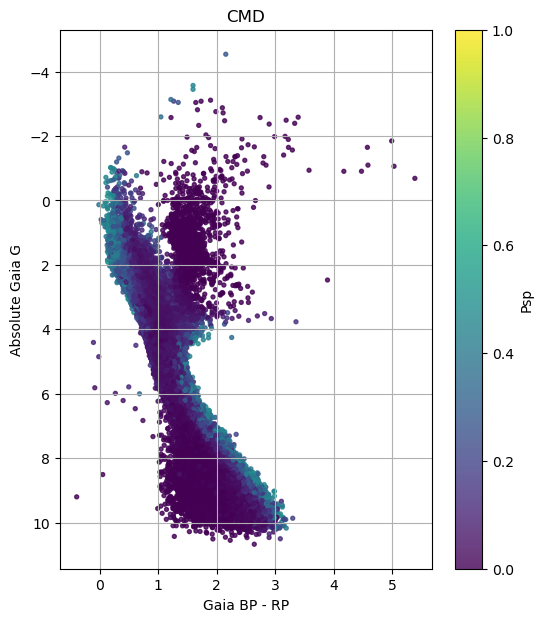

In [25]:
plot_cmd_highlight(df_6, field_cut=0.5)

### Cleaning the Raw Field Sequence

This is the raw field sequence, but it is not yet the clean empirical field sequence we want to model. First, we isolate a reliable underlying field population. Later, we can add Gaia-like uncertainties, binaries, reddening, and other scatter back into the synthetic model.

**Psp**

Above we restricted to Psp below 0.5 to isolate much of the field population. This parameter works better than using either Pyoung or Pmem or both to isolate as it takes both of them into account.

- Pyoung was the probability that the star was less than 50 Myr old 
- Pmem (or Pspatial) was a probability that a star belonged to the young cluster. It was defined through looking at the relative frequencies of high-confidence young and old objects among adjacent stars in space–velocity coordinates 

Basically to calculate Pmem they take a population and had number of young stars being stars with >0.2 Pyoung and old being <0.001 Pyoung. Then they binned candidate groups by D ie. 0 < D < 0.1 etc... 
- In each bin they calculate the number of young stars (if Pyoung >0.2) and the number of old stars
- They then fit a smooth D-Pmem curve based off the relative abundance Pmem(D) = (Nyoung / (Nyoung + Nold)), and then each star gets a Pmem value based off of its D
- See section 5.2 SPYGLASS IV for these curves

The problem is that Pmem is based off of Pyoung. Pyoung implicitly assumes a constant star formation rate ovet the last 11.2 Gyr meaning that over the last 5Myr -> 5Myr / 11.2 Gyr = 0.004 -> 0.4 % of stars in the last 50Myr are young. This is a reasonable baseline for the general field population, but it breaks down near a young cluster

In the local region around a real young association, young stars are much more common than they would be in the background field. Therefore, the prior probability of a star being young should be increased in regions where Pspatial is high.

- We can therefore use the ratio between Pmem and the field abundance of young stars to correct the relative abundances of young and old stars, recalibrating PAge<50 Myr for the environment in which each star is found.
- So Psp is a spatially corrected youth probability
- Ie. if we see that there is a flux of Pmem members in a given area, what should the corrected youth/membership probability be?

This will allow us to isolate the field sequence way more accurately than with Pyoung and/or Pmem

**Quality cut applied:**

The astrometric and photometric quality cuts from SPYGLASS IV are already accounted for through Pyoung: only stars that pass those quality cuts are assigned finite Pyoung values. Therefore, here we keep only stars with non-NaN Pyoung values before applying the CMD-based cleanup.

1. finite Pyoung

**Additional CMD cleanup:**

- remove very bright OB / massive stars:

$$ M_G < 0 $$

- remove the subgiant/evolved branch using a smooth CMD boundary
- remove the lower tail below the main sequence using a smooth CMD boundary

The goal is to clean the field sequence enough to model its average CMD structure, without permanently removing realistic scatter that can be added back later in the synthetic population model.


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def clean_and_plot_field(field_raw):
    """
    Apply SPYGLASS IV-style quality cuts and plot before/after.
    """

    field_raw = add_cmd_columns(field_raw.copy())

    mask = field_raw["Pyoung"].notna()

    # Remove very bright OB / massive stars
    mask &= field_raw["M_G"] > 0.0

    # Remove subgiant / upper branch with a slanted CMD boundary.
    # Removing a line that is parallel to the branch so it doesn't cut off like a box.
    # Stars brighter than this line are removed, but the cut moves fainter at redder colors
    # instead of chopping straight across the CMD.
    UPPER_BRANCH_COLOR_MIN = 0.8
    UPPER_BRANCH_SLOPE = 2.7
    UPPER_BRANCH_INTERCEPT = -0.7

    upper_branch_boundary = (
        UPPER_BRANCH_SLOPE * field_raw["bp_rp"]
        + UPPER_BRANCH_INTERCEPT
    )

    upper_branch_cut = (
        (field_raw["bp_rp"] > UPPER_BRANCH_COLOR_MIN)
        & (field_raw["M_G"] < upper_branch_boundary)
    )

    removed_upper_branch = mask & upper_branch_cut
    mask &= ~upper_branch_cut

    field_clean = field_raw[mask].copy()

    print(f"Raw field sample:   {len(field_raw):,}")
    print(f"After cuts:         {len(field_clean):,}")
    print(f"Removed by slanted upper-branch cut: {removed_upper_branch.sum():,}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

    axes[0].scatter(
        field_raw["bp_rp"],
        field_raw["M_G"],
        s=2,
        alpha=0.12,
        color="black",
        rasterized=True,
    )
    axes[0].set_title(f"Before cuts\nN = {len(field_raw):,}")

    axes[1].scatter(
        field_clean["bp_rp"],
        field_clean["M_G"],
        s=2,
        alpha=0.12,
        color="black",
        rasterized=True,
    )
    axes[1].set_title(f"After cuts\nN = {len(field_clean):,}")

    cut_color_grid = np.linspace(UPPER_BRANCH_COLOR_MIN, 4.0, 200)
    cut_M_G = UPPER_BRANCH_SLOPE * cut_color_grid + UPPER_BRANCH_INTERCEPT

    for ax in axes:
        ax.plot(
            cut_color_grid,
            cut_M_G,
            color="tab:red",
            lw=2,
            label="slanted upper-branch cut",
        )
        ax.set_xlabel("Gaia BP - RP")
        ax.grid(alpha=0.25)
        ax.legend(markerscale=2, fontsize=8)

    axes[0].set_ylabel("Absolute Gaia G")
    axes[0].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return field_clean

Raw field sample:   95,604
After cuts:         93,876
Removed by slanted upper-branch cut: 1,482


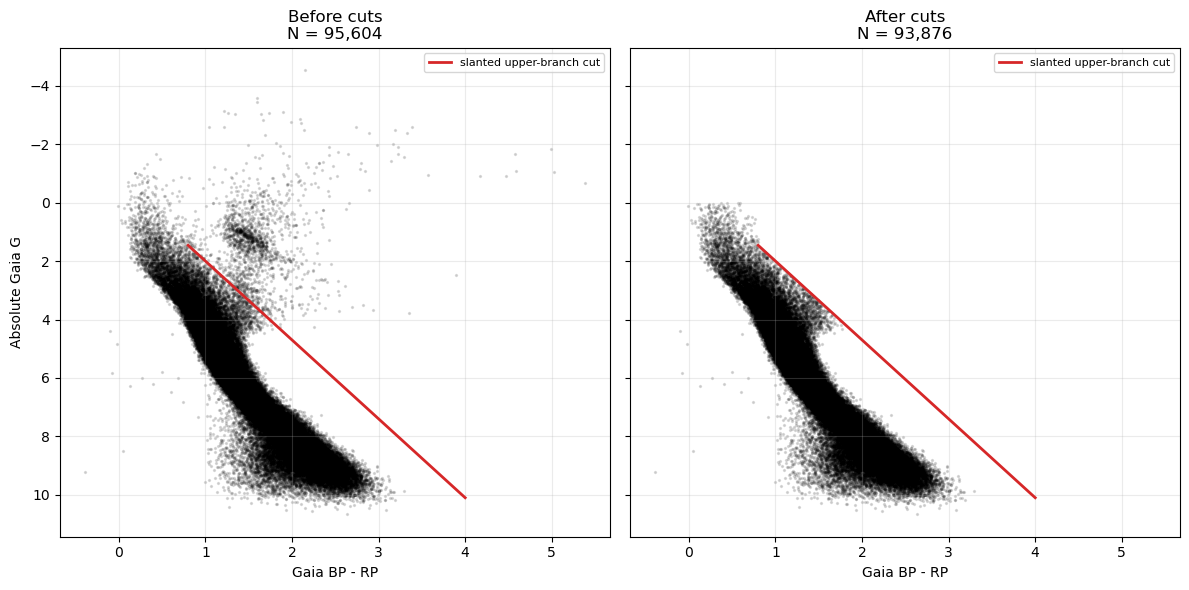

In [27]:
field_raw = df_6[df_6["Psp"] < 0.5].copy()
field_clean = clean_and_plot_field(field_raw)

### Fitting Spline

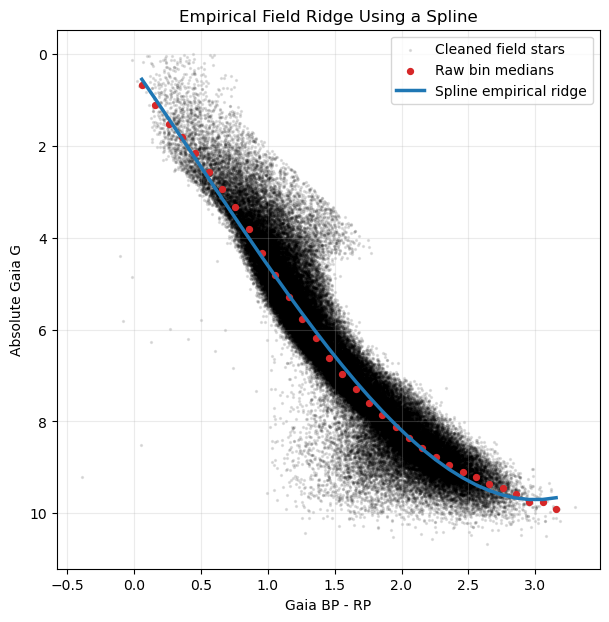

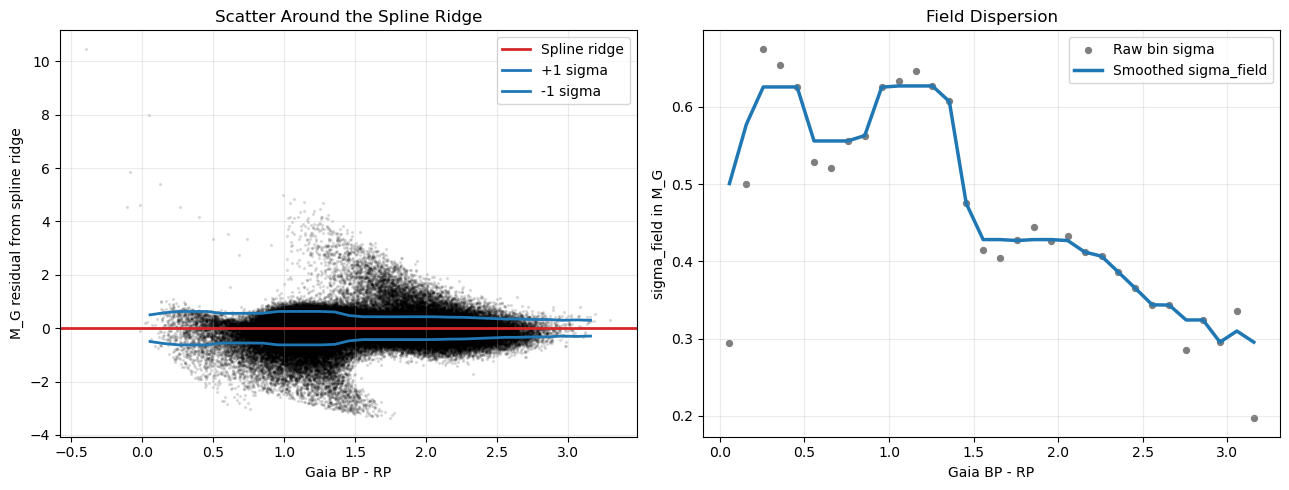

Ridge table:


,bp_rp_center,M_G_ridge_raw,N_stars,M_G_ridge_spline
0,0.056556,0.664155,8,0.550650
1,0.156556,1.119284,78,0.975881
2,0.256556,1.534109,215,1.405655
3,0.356556,1.814983,368,1.838596
4,0.456556,2.162131,550,2.273330


Sigma table:


,bp_rp_center,residual_median,sigma_field,N_stars,sigma_field_smooth
0,0.056556,0.111247,0.294717,8,0.500696
1,0.156556,0.098339,0.500696,78,0.577327
2,0.256556,0.125610,0.675083,215,0.625704
3,0.356556,-0.046340,0.653958,368,0.625704
4,0.456556,-0.122226,0.625704,550,0.625704


In [28]:
# ============================================================
# 1c) Fit an empirical field ridge using a spline
# 1d) Measure the field dispersion around that ridge
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# -----------------------------
# Settings you can tune
# -----------------------------

BIN_WIDTH = 0.10
MIN_STARS_PER_BIN = 5

# Spline smoothing strength.
# Larger = smoother spline.
# Smaller = follows raw median points more closely.
SPLINE_SMOOTHING_FACTOR = 0.05

# Smoothing window for sigma_field only
SMOOTHING_WINDOW = 5


# -----------------------------
# Start from the cleaned field sample
# -----------------------------

field_with_ridge = field_clean.copy()

field_with_ridge = add_cmd_columns(field_with_ridge)

field_with_ridge = field_with_ridge[
    np.isfinite(field_with_ridge["bp_rp"])
    & np.isfinite(field_with_ridge["M_G"])
].copy()


# -----------------------------
# Build BP-RP color bins
# -----------------------------

color_min = field_with_ridge["bp_rp"].min()
color_max = field_with_ridge["bp_rp"].max()

bin_edges = np.arange(color_min, color_max + BIN_WIDTH, BIN_WIDTH) #Create the edges of the bin

# np.digitize returns the bin number for each star, and subtracting by 1 means the bins will be 0-indexed instead of 1-indexed
# We create a new column that contains this number of bin of bp_rp that each star falls into
field_with_ridge["color_bin"] = np.digitize(
    field_with_ridge["bp_rp"],
    bin_edges
) - 1

# 1c) Find raw ridge points

ridge_rows = [] #A ridge point contains: color bin center, median M_G in that color bin, number of stars in the bin

for bin_number in range(len(bin_edges) - 1): #loop over each bin and select only the stars inside that bin
    in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

    if len(in_bin) < MIN_STARS_PER_BIN:
        continue #if there are too few stars in the bin, skip it and do not calculate a ridge point for that bin

    color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1]) #Calculate the center of the color bin to use as the x-value for the ridge point - ie. 0.3-0.4 -> 0.35
    median_M_G = np.median(in_bin["M_G"]) #Calculate the median M_G of the stars in the bin to use as the y-value for the ridge point (good incase there are any outliers)

    ridge_rows.append(
        {
            "bp_rp_center": color_center,
            "M_G_ridge_raw": median_M_G,
            "N_stars": len(in_bin),
        }
    )

ridge_points = pd.DataFrame(ridge_rows)

ridge_points = ridge_points.sort_values("bp_rp_center").reset_index(drop=True) 
# sort points by ridge colour because its expected for the spline fitter to have x values in increasing order


# -----------------------------
# Fit a spline to the ridge points
# -----------------------------

x_ridge = ridge_points["bp_rp_center"].values
y_ridge = ridge_points["M_G_ridge_raw"].values

SPLINE_SMOOTHING = len(ridge_points) * SPLINE_SMOOTHING_FACTOR #This controls how closely the spline follows the raw median ridge points

ridge_spline = UnivariateSpline(
    x_ridge,
    y_ridge,
    s=SPLINE_SMOOTHING
)

ridge_points["M_G_ridge_spline"] = ridge_spline(x_ridge)
# M_G_ridge_raw      = the actual median y-value measured in that bin
# M_G_ridge_spline   = the smoothed curve's y-value at that same x-position
# The spline looks at all the median points together and fits one smooth curve through/near them. 
# So the spline might say: At BP-RP = 0.45, the smooth ridge should be 3.95 to make this curve so that's what applying this function ridge_spline does

field_with_ridge["M_G_ridge"] = ridge_spline(
    field_with_ridge["bp_rp"].values
)
# Remember ridge_spline takes a star’s color, bp_rp, and predicts where the field ridge should be in
# So field_with_ridge["bp_rp"].values gets every star’s BP−RP color: [0.50, 0.70, 1.20]
# Then ridge_spline(field_with_ridge["bp_rp"].values) feeds all those colors into the spline and returns the ridge M_G value at each star's color, so now field_with_ridge["M_G_ridge"] is the predicted M_G value for each one: [4.00, 5.00, 6.80]
# Stores in new column

# Now, M_G_ridge is the value each star gets by following the smooth line created by the spline.
# So the spline creates a smooth curve BP-RP color  →  expected M_G on the field ridge
# Then for each star, the code says: M_G_ridge = ridge_spline(star_bp_rp)



# -----------------------------
# 1d) Measure dispersion around the spline ridge
# -----------------------------

# This calculates how far each star is from the ridge.

field_with_ridge["M_G_residual"] = (
    field_with_ridge["M_G"] - field_with_ridge["M_G_ridge"]
)


sigma_rows = []

for bin_number in range(len(bin_edges) - 1): #Again select colour bins one at a time
    in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

    if len(in_bin) < MIN_STARS_PER_BIN:
        continue

    color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1])

    # In this loop we are looking at the residuals of the spline that we calculated above
    # This is the difference between each star's actual M_G and the M_G value predicted by the spline ridge at that star's color.
    # This gets the 16th, 50th, and 84th percentiles of the residual distribution in that bin.
    # The 50th percentile is the median residual.
    # The 16th and 84th percentiles are used because, for a Gaussian distribution being +- 1 sigma
    # So the range between q16 and q84 captures roughly the central 68% of the stars.
    q16 = np.percentile(in_bin["M_G_residual"], 16)
    q50 = np.percentile(in_bin["M_G_residual"], 50)
    q84 = np.percentile(in_bin["M_G_residual"], 84)

    # sigma_field = 0.5 * (q84 - q16) as subtracting is roughly 2 sigma, so dividing by 2 (or multiplying by 0.5) gives us an estimate of the standard deviation of the residuals in that bin, which we call sigma_field
    sigma_field = 0.5 * (q84 - q16)

    sigma_rows.append(
        {
            "bp_rp_center": color_center,
            "residual_median": q50,
            "sigma_field": sigma_field,
            "N_stars": len(in_bin),
        }
    )

field_sigma_table = pd.DataFrame(sigma_rows)

# This smooths the sigma values in case a bin is contaminated or has a weird sigma value
field_sigma_table["sigma_field_smooth"] = field_sigma_table["sigma_field"].rolling(
    window=SMOOTHING_WINDOW,
    center=True,
    min_periods=1,
).median()

field_with_ridge["sigma_field"] = np.interp(
    field_with_ridge["bp_rp"],
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
)


# -----------------------------
# Plot 1: CMD with empirical spline ridge
# -----------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    field_with_ridge["bp_rp"],
    field_with_ridge["M_G"],
    s=2,
    alpha=0.10,
    color="black",
    rasterized=True,
    label="Cleaned field stars",
)

plt.scatter(
    ridge_points["bp_rp_center"],
    ridge_points["M_G_ridge_raw"],
    s=18,
    color="tab:red",
    label="Raw bin medians",
)

plt.plot(
    ridge_points["bp_rp_center"],
    ridge_points["M_G_ridge_spline"],
    color="tab:blue",
    linewidth=2.5,
    label="Spline empirical ridge",
)

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute Gaia G")
plt.title("Empirical Field Ridge Using a Spline")
plt.gca().invert_yaxis()
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# -----------------------------
# Plot 2: residuals and sigma_field(BP-RP)
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    field_with_ridge["bp_rp"],
    field_with_ridge["M_G_residual"],
    s=2,
    alpha=0.10,
    color="black",
    rasterized=True,
)

axes[0].axhline(
    0,
    color="tab:red",
    linewidth=2,
    label="Spline ridge",
)

axes[0].plot(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2,
    label="+1 sigma",
)

axes[0].plot(
    field_sigma_table["bp_rp_center"],
    -field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2,
    label="-1 sigma",
)

axes[0].set_xlabel("Gaia BP - RP")
axes[0].set_ylabel("M_G residual from spline ridge")
axes[0].set_title("Scatter Around the Spline Ridge")
axes[0].grid(alpha=0.25)
axes[0].legend()


axes[1].scatter(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field"],
    s=18,
    color="tab:gray",
    label="Raw bin sigma",
)

axes[1].plot(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2.5,
    label="Smoothed sigma_field",
)

axes[1].set_xlabel("Gaia BP - RP")
axes[1].set_ylabel("sigma_field in M_G")
axes[1].set_title("Field Dispersion")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


# -----------------------------
# Inspect tables
# -----------------------------

print("Ridge table:")
display(ridge_points.head())

print("Sigma table:")
display(field_sigma_table.head())

Using ridge only up to BP-RP = 2.757
Removed last 4 ridge points from spline fit.


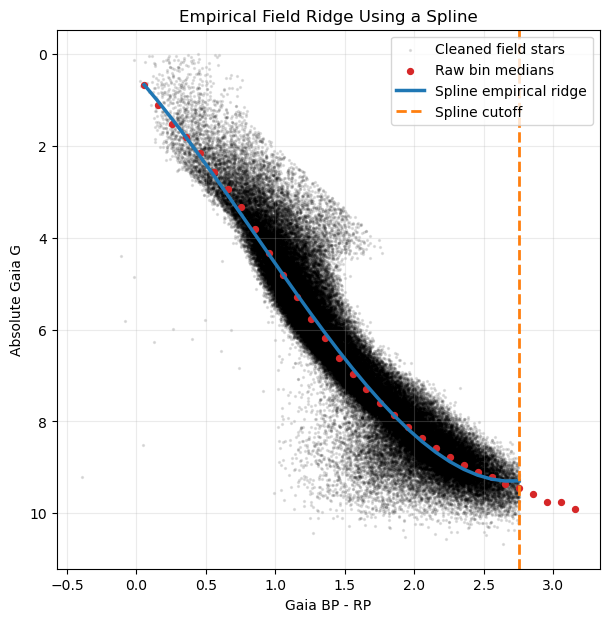

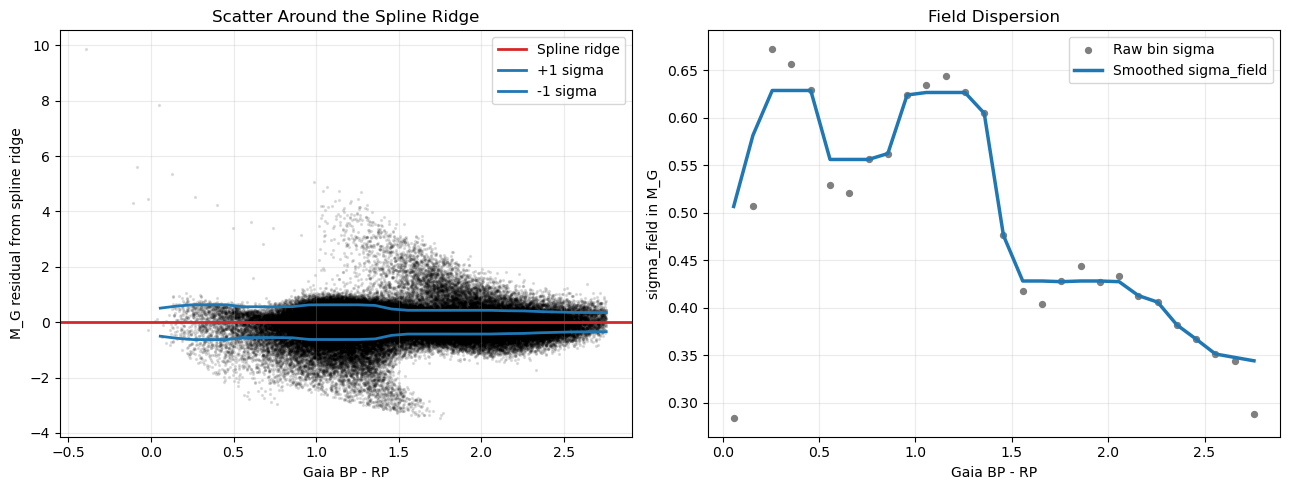

Ridge table:


,bp_rp_center,M_G_ridge_raw,N_stars,M_G_ridge_spline
0,0.056556,0.664155,8,0.669210
1,0.156556,1.119284,78,1.031948
2,0.256556,1.534109,215,1.412907
3,0.356556,1.814983,368,1.809503
4,0.456556,2.162131,550,2.219147


Sigma table:


,bp_rp_center,residual_median,sigma_field,N_stars,sigma_field_smooth
0,0.056556,0.008978,0.283831,8,0.506546
1,0.156556,0.055386,0.506546,78,0.581377
2,0.256556,0.124261,0.672308,215,0.628483
3,0.356556,-0.015132,0.656207,368,0.628483
4,0.456556,-0.066812,0.628483,550,0.628483


In [29]:
# ============================================================
# 1c) Fit an empirical field ridge using a spline
# 1d) Measure the field dispersion around that ridge
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# -----------------------------
# Settings you can tune
# -----------------------------

BIN_WIDTH = 0.10
MIN_STARS_PER_BIN = 5

# Spline smoothing strength.
# Larger = smoother spline.
# Smaller = follows raw median points more closely.
SPLINE_SMOOTHING_FACTOR = 0.05

# Smoothing window for sigma_field only
SMOOTHING_WINDOW = 5

# NEW: removes the last noisy/red-end ridge points before fitting the spline
# Every spline fit for CMD are curving upwards not representative of normal CMD behaviour
# This is because they are hitting a noise floor where the ridge points are not tracing the true ridge anymore but instead are being pulled upwards by outliers or contamination at the red/faint end
CUTOFF_N_FROM_END = 4


# -----------------------------
# Start from the cleaned field sample
# -----------------------------

field_with_ridge = field_clean.copy()

field_with_ridge = add_cmd_columns(field_with_ridge)

field_with_ridge = field_with_ridge[
    np.isfinite(field_with_ridge["bp_rp"])
    & np.isfinite(field_with_ridge["M_G"])
].copy()


# -----------------------------
# Build BP-RP color bins
# -----------------------------

color_min = field_with_ridge["bp_rp"].min()
color_max = field_with_ridge["bp_rp"].max()

bin_edges = np.arange(color_min, color_max + BIN_WIDTH, BIN_WIDTH) #Create the edges of the bin

# np.digitize returns the bin number for each star, and subtracting by 1 means the bins will be 0-indexed instead of 1-indexed
# We create a new column that contains this number of bin of bp_rp that each star falls into
field_with_ridge["color_bin"] = np.digitize(
    field_with_ridge["bp_rp"],
    bin_edges
) - 1

# 1c) Find raw ridge points

ridge_rows = [] #A ridge point contains: color bin center, median M_G in that color bin, number of stars in the bin

for bin_number in range(len(bin_edges) - 1): #loop over each bin and select only the stars inside that bin
    in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

    if len(in_bin) < MIN_STARS_PER_BIN:
        continue #if there are too few stars in the bin, skip it and do not calculate a ridge point for that bin

    color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1]) #Calculate the center of the color bin to use as the x-value for the ridge point - ie. 0.3-0.4 -> 0.35
    median_M_G = np.median(in_bin["M_G"]) #Calculate the median M_G of the stars in the bin to use as the y-value for the ridge point (good incase there are any outliers)

    ridge_rows.append(
        {
            "bp_rp_center": color_center,
            "M_G_ridge_raw": median_M_G,
            "N_stars": len(in_bin),
        }
    )

ridge_points = pd.DataFrame(ridge_rows)

ridge_points = ridge_points.sort_values("bp_rp_center").reset_index(drop=True) 
# sort points by ridge colour because its expected for the spline fitter to have x values in increasing order


# -----------------------------
# NEW: Cut off noisy red/faint end before fitting the spline
# -----------------------------

# new dataframe without the last four rows of ridge points which are the noisiest
ridge_points_fit = ridge_points.iloc[:-CUTOFF_N_FROM_END].copy()

BP_RP_CUTOFF = ridge_points_fit["bp_rp_center"].max()

print(f"Using ridge only up to BP-RP = {BP_RP_CUTOFF:.3f}")
print(f"Removed last {CUTOFF_N_FROM_END} ridge points from spline fit.")


# -----------------------------
# Fit a spline to the ridge points
# -----------------------------

x_ridge = ridge_points_fit["bp_rp_center"].values
y_ridge = ridge_points_fit["M_G_ridge_raw"].values

SPLINE_SMOOTHING = len(ridge_points_fit) * SPLINE_SMOOTHING_FACTOR #This controls how closely the spline follows the raw median ridge points

ridge_spline = UnivariateSpline(
    x_ridge,
    y_ridge,
    s=SPLINE_SMOOTHING
)

ridge_points_fit["M_G_ridge_spline"] = ridge_spline(x_ridge)
# M_G_ridge_raw      = the actual median y-value measured in that bin
# M_G_ridge_spline   = the smoothed curve's y-value at that same x-position
# The spline looks at all the median points together and fits one smooth curve through/near them. 
# So the spline might say: At BP-RP = 0.45, the smooth ridge should be 3.95 to make this curve so that's what applying this function ridge_spline does

# NEW: remove stars past the spline cutoff so the code does not extrapolate into the noisy end
field_with_ridge = field_with_ridge[
    field_with_ridge["bp_rp"] <= BP_RP_CUTOFF
].copy()

field_with_ridge["M_G_ridge"] = ridge_spline(
    field_with_ridge["bp_rp"].values
)
# Remember ridge_spline takes a star’s color, bp_rp, and predicts where the field ridge should be in
# So field_with_ridge["bp_rp"].values gets every star’s BP−RP color: [0.50, 0.70, 1.20]
# Then ridge_spline(field_with_ridge["bp_rp"].values) feeds all those colors into the spline and returns the ridge M_G value at each star's color, so now field_with_ridge["M_G_ridge"] is the predicted M_G value for each one: [4.00, 5.00, 6.80]
# Stores in new column

# Now, M_G_ridge is the value each star gets by following the smooth line created by the spline.
# So the spline creates a smooth curve BP-RP color  →  expected M_G on the field ridge
# Then for each star, the code says: M_G_ridge = ridge_spline(star_bp_rp)



# -----------------------------
# 1d) Measure dispersion around the spline ridge
# -----------------------------

# This calculates how far each star is from the ridge.

field_with_ridge["M_G_residual"] = (
    field_with_ridge["M_G"] - field_with_ridge["M_G_ridge"]
)


sigma_rows = []

for bin_number in range(len(bin_edges) - 1): #Again select colour bins one at a time
    in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

    if len(in_bin) < MIN_STARS_PER_BIN:
        continue

    color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1])

    # In this loop we are looking at the residuals of the spline that we calculated above
    # This is the difference between each star's actual M_G and the M_G value predicted by the spline ridge at that star's color.
    # This gets the 16th, 50th, and 84th percentiles of the residual distribution in that bin.
    # The 50th percentile is the median residual.
    # The 16th and 84th percentiles are used because, for a Gaussian distribution being +- 1 sigma
    # So the range between q16 and q84 captures roughly the central 68% of the stars.
    q16 = np.percentile(in_bin["M_G_residual"], 16)
    q50 = np.percentile(in_bin["M_G_residual"], 50)
    q84 = np.percentile(in_bin["M_G_residual"], 84)

    # sigma_field = 0.5 * (q84 - q16) as subtracting is roughly 2 sigma, so dividing by 2 (or multiplying by 0.5) gives us an estimate of the standard deviation of the residuals in that bin, which we call sigma_field
    sigma_field = 0.5 * (q84 - q16)

    sigma_rows.append(
        {
            "bp_rp_center": color_center,
            "residual_median": q50,
            "sigma_field": sigma_field,
            "N_stars": len(in_bin),
        }
    )

field_sigma_table = pd.DataFrame(sigma_rows)

# This smooths the sigma values in case a bin is contaminated or has a weird sigma value
field_sigma_table["sigma_field_smooth"] = field_sigma_table["sigma_field"].rolling(
    window=SMOOTHING_WINDOW,
    center=True,
    min_periods=1,
).median()

field_with_ridge["sigma_field"] = np.interp(
    field_with_ridge["bp_rp"],
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
)


# -----------------------------
# Plot 1: CMD with empirical spline ridge
# -----------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    field_with_ridge["bp_rp"],
    field_with_ridge["M_G"],
    s=2,
    alpha=0.10,
    color="black",
    rasterized=True,
    label="Cleaned field stars",
)

plt.scatter(
    ridge_points["bp_rp_center"],
    ridge_points["M_G_ridge_raw"],
    s=18,
    color="tab:red",
    label="Raw bin medians",
)

plt.plot(
    ridge_points_fit["bp_rp_center"],
    ridge_points_fit["M_G_ridge_spline"],
    color="tab:blue",
    linewidth=2.5,
    label="Spline empirical ridge",
)

plt.axvline(
    BP_RP_CUTOFF,
    color="tab:orange",
    linestyle="--",
    linewidth=2,
    label="Spline cutoff",
)

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute Gaia G")
plt.title("Empirical Field Ridge Using a Spline")
plt.gca().invert_yaxis()
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# -----------------------------
# Plot 2: residuals and sigma_field(BP-RP)
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    field_with_ridge["bp_rp"],
    field_with_ridge["M_G_residual"],
    s=2,
    alpha=0.10,
    color="black",
    rasterized=True,
)

axes[0].axhline(
    0,
    color="tab:red",
    linewidth=2,
    label="Spline ridge",
)

axes[0].plot(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2,
    label="+1 sigma",
)

axes[0].plot(
    field_sigma_table["bp_rp_center"],
    -field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2,
    label="-1 sigma",
)

axes[0].set_xlabel("Gaia BP - RP")
axes[0].set_ylabel("M_G residual from spline ridge")
axes[0].set_title("Scatter Around the Spline Ridge")
axes[0].grid(alpha=0.25)
axes[0].legend()


axes[1].scatter(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field"],
    s=18,
    color="tab:gray",
    label="Raw bin sigma",
)

axes[1].plot(
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
    color="tab:blue",
    linewidth=2.5,
    label="Smoothed sigma_field",
)

axes[1].set_xlabel("Gaia BP - RP")
axes[1].set_ylabel("sigma_field in M_G")
axes[1].set_title("Field Dispersion")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


# -----------------------------
# Inspect tables
# -----------------------------

print("Ridge table:")
display(ridge_points_fit.head())

print("Sigma table:")
display(field_sigma_table.head())

**Now we can use a 1 Gyr Isochrone as a Sampling Backbone**
- We use a representative old isochrone, such as a 1 Gyr isochrone, as a backbone for generating a synthetic field population. This isochrone is not assumed to represent the true field population. 

The IMF is used to sample stellar masses, and the isochrone converts those masses into Gaia magnitudes and colors. This produces a clean synthetic sequence that can then be corrected using the empirical field ridge.

**Then we will warp the Synthetic Stars onto the Empirical Field Spline**

The empirical field spline represents the measured ridge line of the cleaned field population. Since the real field is a mixture of ages, metallicities, binaries, observational errors, and selection effects, a single 1 Gyr isochrone will not perfectly describe the field sequence.

To correct this, we shift the synthetic stars so that their central ridge follows the empirical spline. For each synthetic star, we evaluate the spline at its BP-RP color and use this value as the expected field-sequence magnitude. ie. $ M_{G,\mathrm{ridge}} = \mathrm{spline}(BP-RP)$
- The synthetic CMD is therefore anchored to the observed field sequence rather than relying only on the theoretical isochrone.

**Add Scatter Around the Field Ridge**

After warping the synthetic stars onto the empirical field ridge, we add vertical scatter using the measured field dispersion:

$ M_{G,\mathrm{synthetic}} = M_{G,\mathrm{ridge}} + \mathcal{N}(0, \sigma_{\mathrm{field}}(BP-RP))$

where $\sigma_{\mathrm{field}}(BP-RP)$ is measured from the residuals of the real field stars around the spline ridge.

In [30]:
# ============================================================
# 1e) Load and prepare the 1 Gyr isochrone
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ISO_PATH = "Old_Isochrones (>1 Gyr).txt"

N_SYNTH = 10_000

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)


# -----------------------------
# Load the PARSEC isochrone file
# -----------------------------

# Grab the column names 
with open(ISO_PATH, "r") as f:
    for line in f:
        if line.startswith("#") and "logAge" in line and "Gmag" in line:
            iso_columns = line.replace("#", "").split()
            break

iso_all = pd.read_csv(
    ISO_PATH,
    sep=r"\s+",
    comment="#",
    names=iso_columns,
    engine="python"
)

print("Isochrone table shape:", iso_all.shape)
print("Isochrone columns:")
print(list(iso_all.columns))

# -----------------------------
# Select the 1 Gyr isochrone
# -----------------------------

# In PARSEC, logAge = log10(age in years).
# Therefore:
# 1 Gyr = 10^9 years
# logAge = 9.0

TARGET_LOGAGE = 9.0

available_logages = np.sort(iso_all["logAge"].unique())
# Pick the isochrone closes to logage of 1 Gyr because the table is not exact so find residual for 1Gyr and closest is the chosen
chosen_logage = available_logages[np.argmin(np.abs(available_logages - TARGET_LOGAGE))] 

# Select all rows in the full isochrone table whose logAge matches the chosen 1 Gyr logAge. 
# Using isclose because sometimes the values might not be exactly equal because of machine precision
iso_1gyr = iso_all[np.isclose(iso_all["logAge"], chosen_logage)].copy()

print(f"\nSelected logAge = {chosen_logage:.3f}")
print(f"Number of rows in selected isochrone: {len(iso_1gyr)}")

#iso_backbone is the subset of the 1 Gyr isochrone that only contains the main sequence backbone, which is defined as the rows where the "label" column is either 0 or 1
# label 0 or 1 represent the main sequence in the PARSEC isochrone -> other labels later evolution and have weird CMD behaviours 
iso_backbone = iso_1gyr[iso_1gyr["label"].isin([0, 1])].copy()

print(f"Rows after keeping PARSEC labels 0/1: {len(iso_backbone)}")

# -----------------------------
# Build CMD columns
# -----------------------------

# Mini is just the mass coordinate along the isochrone line.
# It makes up the curve just like BP-RP and M_G do, so we can use it as the mass coordinate for sampling.
# Use initial mass as the sampling mass because it is the mass the IMF refers to
iso_backbone["mass_sample"] = iso_backbone["Mini"]

# Gaia color
iso_backbone["bp_rp"] = iso_backbone["G_BPmag"] - iso_backbone["G_RPmag"]

# PARSEC magnitudes are absolute magnitudes, so Gmag is M_G.
iso_backbone["M_G"] = iso_backbone["Gmag"]


# -----------------------------
# Restrict to the empirical spline/color range
# -----------------------------

# The synthetic population should only be created over the color range where
# the empirical field spline and sigma table are defined.
# This avoids extrapolating the spline beyond the observed field sequence.

ridge_color_min = ridge_points["bp_rp_center"].min()
ridge_color_max = ridge_points["bp_rp_center"].max()

sigma_color_min = field_sigma_table["bp_rp_center"].min()
sigma_color_max = field_sigma_table["bp_rp_center"].max()

empirical_color_min = max(ridge_color_min, sigma_color_min)
empirical_color_max = min(ridge_color_max, sigma_color_max)

iso_backbone = iso_backbone[
    iso_backbone["bp_rp"].between(empirical_color_min, empirical_color_max)
].copy()

print(
    f"Empirical color range used: "
    f"{empirical_color_min:.3f} <= BP-RP <= {empirical_color_max:.3f}"
)
print(f"Rows after color cut: {len(iso_backbone)}")


# -----------------------------
# Prepare table for interpolation
# -----------------------------

# Keep only the columns needed for synthetic sampling.
iso_interp = iso_backbone[
    [
        "mass_sample",
        "Mass",
        "Gmag",
        "G_BPmag",
        "G_RPmag",
        "bp_rp",
        "M_G",
        "label",
    ]
].copy()

# Remove bad values and make sure mass is sorted.
iso_interp = (
    iso_interp
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("mass_sample")
    .drop_duplicates(subset="mass_sample", keep="first")
    .reset_index(drop=True)
)

print("\nPrepared 1 Gyr isochrone backbone:")
display(iso_interp.head())

print(
    f"\nMass range used for sampling: "
    f"{iso_interp['mass_sample'].min():.3f} - "
    f"{iso_interp['mass_sample'].max():.3f} Msun"
)

print(
    f"Color range used for sampling: "
    f"{iso_interp['bp_rp'].min():.3f} - "
    f"{iso_interp['bp_rp'].max():.3f}"
)

Isochrone table shape: (2517, 31)
Isochrone columns:
['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Gmag', 'G_BPmag', 'G_RPmag']

Selected logAge = 9.000
Number of rows in selected isochrone: 642
Rows after keeping PARSEC labels 0/1: 90
Empirical color range used: 0.057 <= BP-RP <= 2.757
Rows after color cut: 81

Prepared 1 Gyr isochrone backbone:


,mass_sample,Mass,Gmag,G_BPmag,G_RPmag,bp_rp,M_G,label
0,0.313931,0.314,10.842,12.341,9.653,2.688,10.842,0
1,0.319859,0.320,10.786,12.273,9.600,2.673,10.786,0
2,0.347600,0.348,10.542,11.974,9.374,2.600,10.542,0
3,0.350000,0.350,10.522,11.950,9.355,2.595,10.522,0
4,0.400000,0.400,10.070,11.403,8.936,2.467,10.070,0



Mass range used for sampling: 0.314 - 2.108 Msun
Color range used for sampling: 0.210 - 2.688


### Sample Stars Along Isochrone

In [31]:
# ============================================================
# 1f) Sample stars along the 1 Gyr isochrone using an IMF
# ============================================================

# The isochrone gives the CMD location for each possible initial mass.
# The IMF tells us how often each mass should be sampled.
# Low-mass stars are common, high-mass stars are rare.

import math


# -----------------------------
# Define a Chabrier 2005 IMF
# -----------------------------
# This code uses a Chabrier 2005-style IMF, where low masses are sampled from a lognormal distribution and high masses are sampled from a Salpeter-like power law. 
# That matches the SPYGLASS idea: the paper says the model population uses the Chabrier 2005 single-star/system-like IMF, which is lognormal below 1 Msun and a power law above 1 Msun.

def sample_powerlaw(m_min, m_max, alpha, size, rng):
    """
    Sample masses from a power law:
    
        p(m) ∝ m^(-alpha)
    
    Larger alpha means high-mass stars become rarer.
    """
    u = rng.random(size) #Uniform random numbers between 0 and 1 the number of random numbers is "size"

    exponent = 1.0 - alpha #This is the integral exponent for the cumulative distribution function (CDF) of the power law. The CDF is proportional to m^(1-alpha), so the exponent is 1 - alpha.

    # This converts the uniform random numbers u into masses that follow the power-law IMF.
    return (
        u * (m_max**exponent - m_min**exponent)
        + m_min**exponent
    ) ** (1.0 / exponent)

def sample_truncated_lognormal(log10_mean, log10_sigma, m_min, m_max, size, rng):
    """
    Sample from a lognormal distribution in log10(mass), then keep only
    masses inside the requested isochrone mass range.

    This is the low-mass part of the Chabrier IMF.
    Chabrier writes it as a Gaussian in log10(mass), not in mass itself.
    """
    masses = []
    needed = size

    while needed > 0:
        # Draw a little extra so the rejection step finishes quickly.
        trial_size = max(needed * 2, 100)
        log_m = rng.normal(log10_mean, log10_sigma, trial_size)
        trial_masses = 10 ** log_m

        keep = trial_masses[
            (trial_masses >= m_min)
            & (trial_masses <= m_max)
        ]

        masses.append(keep[:needed])
        needed -= len(keep[:needed])

    return np.concatenate(masses)


def normal_cdf(x, mu, sigma):
    """
    Normal CDF without needing scipy.stats.

    This is only used to calculate the relative probability in the
    low-mass Chabrier lognormal segment.
    """
    return 0.5 * (1.0 + math.erf((x - mu) / (sigma * np.sqrt(2.0))))


def sample_chabrier_2005_imf(size, m_min, m_max, rng):
    """
    Sample stellar masses from a Chabrier 2005-style IMF.

    Low masses, m <= 1 Msun:
        lognormal in log10(m), centered near 0.2 Msun.

    High masses, m > 1 Msun:
        Salpeter-like power-law tail, dN/dm proportional to m^-2.35.

    The constants below set the relative amount of low-mass and high-mass
    stars using the usual Chabrier parameterization. The exact normalization
    cancels because we only need probabilities.
    """
    break_mass = 1.0

    # Chabrier 2005 single-star/system-like parameters often used in practice.
    # The IMF is lognormal below 1 Msun in log10(mass).
    log10_mc = np.log10(0.2)
    sigma_log10 = 0.55
    low_norm = 0.093

    # Above 1 Msun, Chabrier joins onto a Salpeter-like tail.
    high_alpha_dm = 2.35
    high_alpha_dlogm = high_alpha_dm - 1.0
    high_norm = 0.041

    segments = []

    # Low-mass lognormal segment, integrated over log10(m).
    if m_min < break_mass:
        low_min = m_min
        low_max = min(m_max, break_mass)

        x_min = np.log10(low_min)
        x_max = np.log10(low_max)

        low_weight = low_norm * sigma_log10 * np.sqrt(2.0 * np.pi) * (
            normal_cdf(x_max, log10_mc, sigma_log10)
            - normal_cdf(x_min, log10_mc, sigma_log10)
        )

        segments.append(("lognormal", low_min, low_max, low_weight))

    # High-mass power-law segment, integrated over log10(m).
    if m_max > break_mass:
        high_min = max(m_min, break_mass)
        high_max = m_max

        x_min = np.log10(high_min)
        x_max = np.log10(high_max)

        high_weight = high_norm * (
            10 ** (-high_alpha_dlogm * x_min)
            - 10 ** (-high_alpha_dlogm * x_max)
        ) / (high_alpha_dlogm * np.log(10.0))

        segments.append(("powerlaw", high_min, high_max, high_weight))

    if len(segments) == 0:
        raise ValueError("Invalid IMF mass range.")

    weights = np.array([segment[3] for segment in segments], dtype=float)
    weights = weights / weights.sum()

    chosen_segments = rng.choice(len(segments), size=size, p=weights)
    masses = np.empty(size)

    for i, (kind, seg_min, seg_max, _) in enumerate(segments):
        mask = chosen_segments == i
        n_segment = mask.sum()

        if n_segment == 0:
            continue

        if kind == "lognormal":
            masses[mask] = sample_truncated_lognormal(
                log10_mean=log10_mc,
                log10_sigma=sigma_log10,
                m_min=seg_min,
                m_max=seg_max,
                size=n_segment,
                rng=rng,
            )
        else:
            masses[mask] = sample_powerlaw(
                seg_min,
                seg_max,
                alpha=high_alpha_dm,
                size=n_segment,
                rng=rng,
            )

    rng.shuffle(masses)

    return masses


# -----------------------------
# Draw synthetic masses
# -----------------------------

# Use the mass range covered by the cleaned 1 Gyr isochrone backbone.
m_min = iso_interp["mass_sample"].min()
m_max = iso_interp["mass_sample"].max()

print(f"Sampling synthetic masses from {m_min:.3f} to {m_max:.3f} Msun")

# This draws N_SYNTH random masses from the Chabrier 2005 IMF, restricted to the mass range of the isochrone backbone. 
# These masses will then be mapped to CMD positions using the isochrone.
# They will naturally favor low masses because the Chabrier IMF has more low-mass stars than high-mass stars
synth_mass = sample_chabrier_2005_imf(
    size=N_SYNTH,
    m_min=m_min,
    m_max=m_max,
    rng=rng,
)

synth = pd.DataFrame({
    "mass_sample": synth_mass
})


# -----------------------------
# Interpolate isochrone values onto sampled masses
# -----------------------------

# The isochrone is a mass-to-CMD map.
# For each sampled mass, interpolate the corresponding Gaia magnitudes and color.

# iso_interp['mass_sample'] is the mass column in the isochrone table -> just the mass axis of the isochrone for plotting the line on CMD
# For each column in the isochrone that we want to assign to the synthetic population (Gmag, G_BPmag, G_RPmag, bp_rp, M_G), we use np.interp to interpolate the value of that column at the sampled mass values in synth["mass_sample"] based on the isochrone values in iso_interp.
# iso_interp is like a lookup table
# np.interp estimates the Gaia values between nearby isochrone points in case it doesn't land exactly on an isochrone point. So if we sampled a mass of 0.35 Msun but the isochrone only has points at 0.3 and 0.4 Msun, np.interp will look at the Gaia values at 0.3 and 0.4 Msun and estimate what the Gaia values would be at 0.35 Msun by assuming a linear change between those two points.

for col in ["Gmag", "G_BPmag", "G_RPmag", "bp_rp", "M_G"]:
    synth[col] = np.interp(
        synth["mass_sample"],
        iso_interp["mass_sample"],
        iso_interp[col],
    )


# -----------------------------
# Inspect the synthetic backbone population
# -----------------------------

print("Synthetic isochrone-sampled population before empirical warping:")
display(synth.head())

print("\nSynthetic population shape:", synth.shape)

print(
    f"Synthetic BP-RP range: "
    f"{synth['bp_rp'].min():.3f} - {synth['bp_rp'].max():.3f}"
)

Sampling synthetic masses from 0.314 to 2.108 Msun
Synthetic isochrone-sampled population before empirical warping:


,mass_sample,Gmag,G_BPmag,G_RPmag,bp_rp,M_G
0,0.916968,5.348103,5.739003,4.788727,0.950276,5.348103
1,0.753166,6.519310,7.073636,5.813510,1.260127,6.519310
2,0.499030,9.142335,10.288237,8.082539,2.205698,9.142335
3,1.744858,1.844343,1.940853,1.664321,0.276532,1.844343
4,0.618018,7.887266,8.751908,6.973934,1.777974,7.887266



Synthetic population shape: (10000, 6)
Synthetic BP-RP range: 0.259 - 2.688


### Wrap Synthetic Stars onto empirical spline

One important subtlety: this warp is mostly vertical. The code keeps bp_rp fixed and changes M_G. It is not moving stars perpendicular to the spline curve. That is fine for a CMD model if you want “at this color, what magnitude should the field ridge have?” But it means the final model preserves the color distribution from the 1 Gyr sampled population, not necessarily the exact full 2D density of the real field.

In [32]:
# ============================================================
# 1g) Warp synthetic stars onto the empirical field spline
# ============================================================

# The 1 Gyr isochrone was only used as a sampling backbone.
# It gave us a reasonable distribution of masses and colors.
# Now we force the synthetic population to follow the observed field ridge (the spline we fitted)


# For each synthetic star, use its BP-RP color to find the expected field-sequence M_G from the empirical spline.
# This is the main wrapping part. We say for every synthetic star, keep its bp_rp 
# Then ask at this colour, where does the empirical field spline say the field ridge should be in M_G
# But, we haven't accounted for the fact that the field sequence has some width, which we add in next steps
synth["M_G_ridge"] = ridge_spline(synth["bp_rp"])


# -----------------------------
# Interpolate the field scatter
# -----------------------------

# The sigma table tells us how wide the observed field sequence is as a function of BP-RP color.
# We ask at each colour how wide is the field seqeunce by looking at the sigma_field column in the field_sigma_table, which is the smoothed version of the raw sigma measurements.
synth["sigma_field"] = np.interp(
    synth["bp_rp"],
    field_sigma_table["bp_rp_center"],
    field_sigma_table["sigma_field_smooth"],
)


# -----------------------------
# Add vertical scatter around the ridge
# -----------------------------

# Keep each star's color fixed, but scatter its M_G value up/down
# using the measured field width at that color.
synth["M_G_synth"] = synth["M_G_ridge"] + rng.normal(
    loc=0.0,
    scale=synth["sigma_field"],
    size=len(synth),
)


# -----------------------------
# Final synthetic field catalog
# -----------------------------

synthetic_field = synth.copy()

print("Warped synthetic field population:")
display(
    synthetic_field[
        ["mass_sample", "bp_rp", "M_G_ridge", "sigma_field", "M_G_synth"]
    ].head()
)

Warped synthetic field population:


,mass_sample,bp_rp,M_G_ridge,sigma_field,M_G_synth
0,0.916968,0.950276,4.345249,0.619888,4.406763
1,0.753166,1.260127,5.670586,0.625605,5.697980
2,0.499030,2.205698,8.777324,0.409449,8.553302
3,1.744858,0.276532,1.490965,0.628483,1.025127
4,0.618018,1.777974,7.626009,0.427592,7.965202


### Plotting:

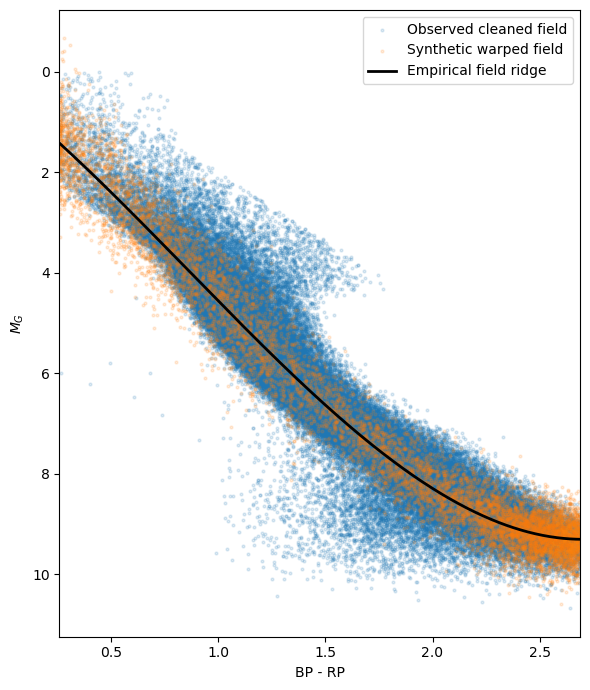

In [33]:
# Quick sanity plot
# This plot compares the observed cleaned field to the synthetic field model.
# The ridge spline is plotted only over the supported color interval, not over
# the full synthetic/axis range. That avoids the unphysical edge behavior where
# the spline can curve back after the actual isochrone/backbone has stopped.

# Rebuild this small clean sigma table here so the plot cell can be run by itself.
# The previous cell uses field_sigma_table directly, so sigma_table may not exist
# if you restarted the kernel or only reran the plotting cell.
sigma_table = (
    field_sigma_table[["bp_rp_center", "sigma_field_smooth"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("bp_rp_center")
)

plot_color_min = max(
    empirical_color_min,
    sigma_table["bp_rp_center"].min(),
    synthetic_field["bp_rp"].min(),
)
plot_color_max = min(
    empirical_color_max,
    sigma_table["bp_rp_center"].max(),
    synthetic_field["bp_rp"].max(),
)

# Make sure the observed field sample has the CMD columns used in the plot.
field_plot_base = add_cmd_columns(field_clean.copy())

field_plot = field_plot_base[
    field_plot_base["bp_rp"].between(plot_color_min, plot_color_max)
    & np.isfinite(field_plot_base["bp_rp"])
    & np.isfinite(field_plot_base["M_G"])
].copy()

color_grid = np.linspace(plot_color_min, plot_color_max, 500)

plt.figure(figsize=(6, 7))

plt.scatter(
    field_plot["bp_rp"],
    field_plot["M_G"],
    s=4,
    alpha=0.15,
    label="Observed cleaned field",
)

plt.scatter(
    synthetic_field["bp_rp"],
    synthetic_field["M_G_synth"],
    s=4,
    alpha=0.15,
    label="Synthetic warped field",
)

plt.plot(
    color_grid,
    ridge_spline(color_grid),
    color="black",
    lw=2,
    label="Empirical field ridge",
)

plt.gca().invert_yaxis()
plt.xlim(plot_color_min, plot_color_max)
plt.xlabel("BP - RP")
plt.ylabel(r"$M_G$")
plt.legend()
plt.tight_layout()
plt.show()

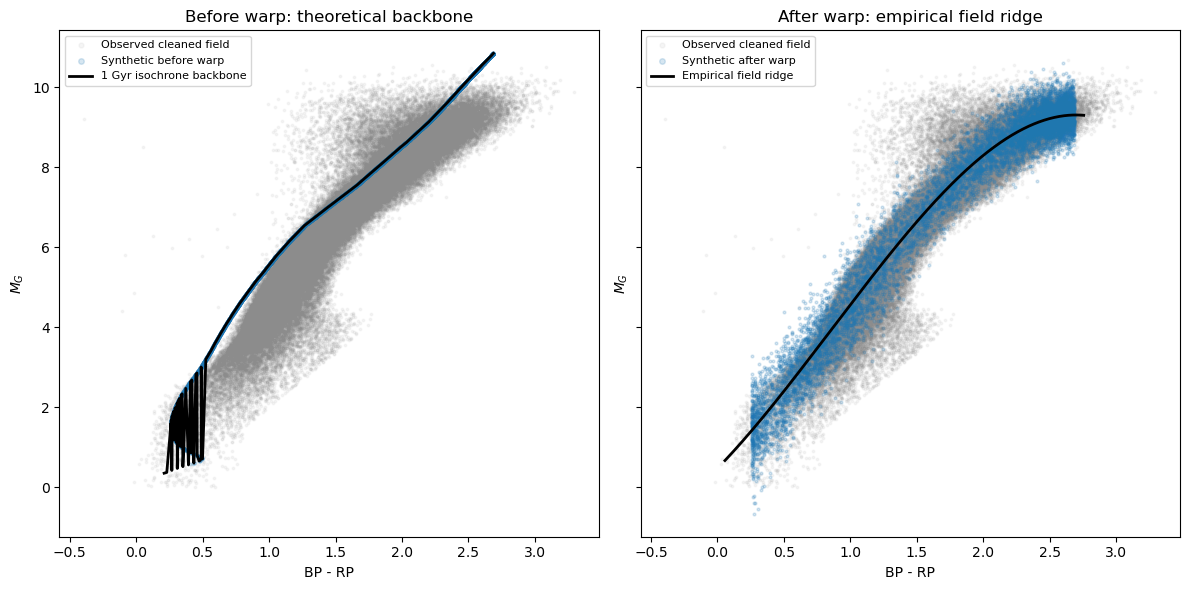

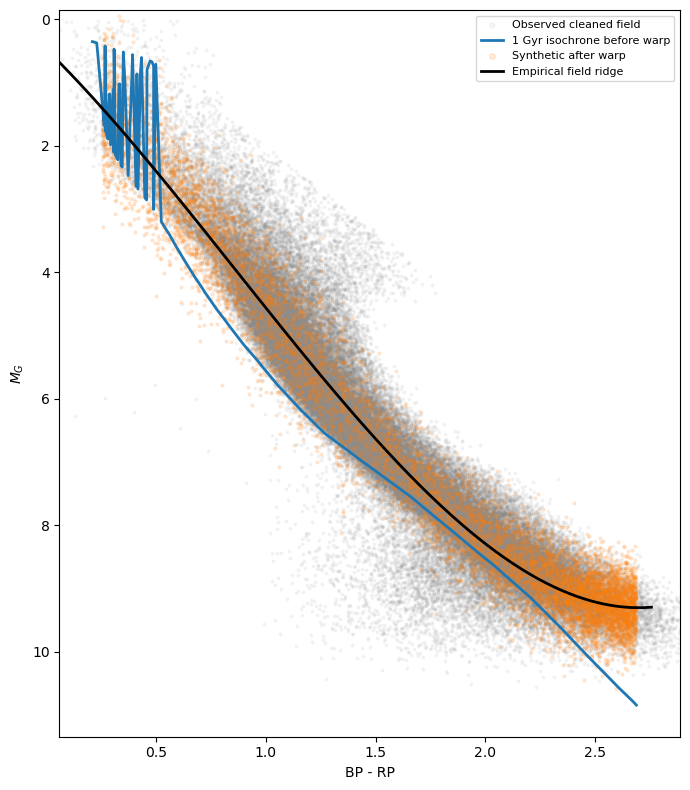

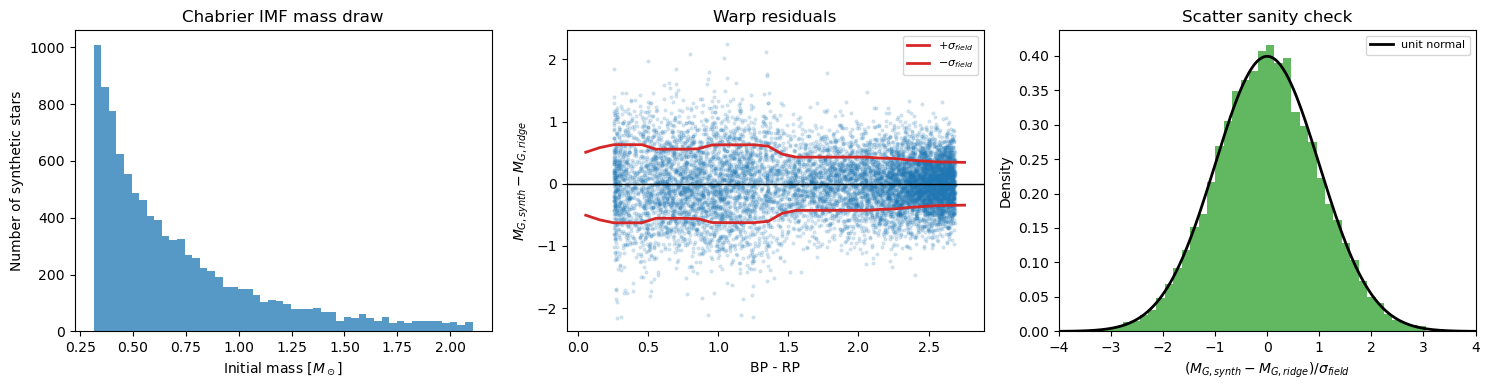

In [34]:
# ============================================================
# Extra diagnostic plots for the synthetic field population
# ============================================================

# These plots are meant to answer three quick questions:
# 1. What did the synthetic stars look like before the empirical warp?
# 2. What changed after forcing them onto the observed field ridge?
# 3. Does the added scatter look like the sigma_field model we measured?

# Make a clean observed-field table for plotting.
field_diag = add_cmd_columns(field_clean.copy())
field_diag = field_diag[
    np.isfinite(field_diag["bp_rp"])
    & np.isfinite(field_diag["M_G"])
].copy()

# Make a clean sigma table in this cell too, so the diagnostics can be rerun
# even if only this cell is executed after a kernel restart.
sigma_table_diag = (
    field_sigma_table[["bp_rp_center", "sigma_field_smooth"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("bp_rp_center")
)

# The ridge is only trustworthy over the color range where it was measured.
ridge_color_grid = np.linspace(empirical_color_min, empirical_color_max, 500)

# Sort the isochrone backbone by color for plotting it as a smooth line.
# This is the "normal" theoretical 1 Gyr sequence before any empirical warp.
iso_plot = iso_interp.sort_values("bp_rp").copy()


# ------------------------------------------------------------
# Plot 1: before vs after warp
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes[0].scatter(
    field_diag["bp_rp"],
    field_diag["M_G"],
    s=3,
    alpha=0.08,
    color="0.55",
    label="Observed cleaned field",
)
axes[0].scatter(
    synth["bp_rp"],
    synth["M_G"],
    s=4,
    alpha=0.18,
    label="Synthetic before warp",
)
axes[0].plot(
    iso_plot["bp_rp"],
    iso_plot["M_G"],
    color="black",
    lw=2,
    label="1 Gyr isochrone backbone",
)
axes[0].set_title("Before warp: theoretical backbone")

axes[1].scatter(
    field_diag["bp_rp"],
    field_diag["M_G"],
    s=3,
    alpha=0.08,
    color="0.55",
    label="Observed cleaned field",
)
axes[1].scatter(
    synthetic_field["bp_rp"],
    synthetic_field["M_G_synth"],
    s=4,
    alpha=0.18,
    label="Synthetic after warp",
)
axes[1].plot(
    ridge_color_grid,
    ridge_spline(ridge_color_grid),
    color="black",
    lw=2,
    label="Empirical field ridge",
)
axes[1].set_title("After warp: empirical field ridge")

for ax in axes:
    ax.invert_yaxis()
    ax.set_xlabel("BP - RP")
    ax.set_ylabel(r"$M_G$")
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: zoomed-out CMD overlay
# ------------------------------------------------------------

# This version intentionally uses a wider CMD view so it is easier to see
# where the theoretical isochrone sits relative to the observed field.
x_min = min(
    field_diag["bp_rp"].quantile(0.005),
    iso_plot["bp_rp"].min(),
    synthetic_field["bp_rp"].min(),
) - 0.15
x_max = max(
    field_diag["bp_rp"].quantile(0.995),
    iso_plot["bp_rp"].max(),
    synthetic_field["bp_rp"].max(),
) + 0.15

y_min = min(
    field_diag["M_G"].quantile(0.005),
    iso_plot["M_G"].min(),
    synthetic_field["M_G_synth"].quantile(0.005),
) - 0.5
y_max = max(
    field_diag["M_G"].quantile(0.995),
    iso_plot["M_G"].max(),
    synthetic_field["M_G_synth"].quantile(0.995),
) + 0.5

plt.figure(figsize=(7, 8))

plt.scatter(
    field_diag["bp_rp"],
    field_diag["M_G"],
    s=3,
    alpha=0.08,
    color="0.55",
    label="Observed cleaned field",
)
plt.plot(
    iso_plot["bp_rp"],
    iso_plot["M_G"],
    color="tab:blue",
    lw=2,
    label="1 Gyr isochrone before warp",
)
plt.scatter(
    synthetic_field["bp_rp"],
    synthetic_field["M_G_synth"],
    s=4,
    alpha=0.14,
    color="tab:orange",
    label="Synthetic after warp",
)
plt.plot(
    ridge_color_grid,
    ridge_spline(ridge_color_grid),
    color="black",
    lw=2,
    label="Empirical field ridge",
)

plt.gca().invert_yaxis()
plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)
plt.xlabel("BP - RP")
plt.ylabel(r"$M_G$")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 3: mass sampling and scatter checks
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chabrier IMF check: most sampled stars should be low mass.
axes[0].hist(synthetic_field["mass_sample"], bins=50, color="tab:blue", alpha=0.75)
axes[0].set_xlabel(r"Initial mass [$M_\odot$]")
axes[0].set_ylabel("Number of synthetic stars")
axes[0].set_title("Chabrier IMF mass draw")

# Vertical residuals after the warp should be centered near zero.
cmd_residual = synthetic_field["M_G_synth"] - synthetic_field["M_G_ridge"]
axes[1].scatter(
    synthetic_field["bp_rp"],
    cmd_residual,
    s=4,
    alpha=0.15,
)
axes[1].axhline(0, color="black", lw=1)
axes[1].plot(
    sigma_table_diag["bp_rp_center"],
    sigma_table_diag["sigma_field_smooth"],
    color="tab:red",
    lw=2,
    label=r"$+\sigma_{field}$",
)
axes[1].plot(
    sigma_table_diag["bp_rp_center"],
    -sigma_table_diag["sigma_field_smooth"],
    color="tab:red",
    lw=2,
    label=r"$-\sigma_{field}$",
)
axes[1].set_xlabel("BP - RP")
axes[1].set_ylabel(r"$M_{G,synth} - M_{G,ridge}$")
axes[1].set_title("Warp residuals")
axes[1].legend(fontsize=8)

# Standardized residuals should look roughly like a unit normal distribution.
standardized_residual = cmd_residual / synthetic_field["sigma_field"]
axes[2].hist(standardized_residual, bins=50, density=True, alpha=0.75, color="tab:green")

normal_x = np.linspace(-4, 4, 300)
normal_y = np.exp(-0.5 * normal_x**2) / np.sqrt(2 * np.pi)
axes[2].plot(normal_x, normal_y, color="black", lw=2, label="unit normal")
axes[2].set_xlim(-4, 4)
axes[2].set_xlabel(r"$(M_{G,synth} - M_{G,ridge}) / \sigma_{field}$")
axes[2].set_ylabel("Density")
axes[2].set_title("Scatter sanity check")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Master Field Sequence

With all of this code created, we can now create a master field sequence by combining all SCYA clusters. We will want to bin the SCYA clusters by distance becasue their distances affect their sigma values as Gaia parallax uncertainty changes depending on its distance

The code will do the following:

What the new cell does:

Loads all CLUSTER_ALLDATA_SCYA*.csv files from ../SCYA_all/SCYA_Pkg.

Estimates each cluster distance using the average d of the top 10 percent highest-strength stars.
Assigns clusters into distance bins: 0-250, 250-400, 400-600, 600-800, 800-1000 pc.

Stacks all stars from clusters in each distance bin.

Computes Psp for every star using your existing Psp() function.

Applies the cuts: Psp < 0.5, finite Pyoung, remove OB stars with M_G > 0, and remove the slanted upper branch, remove white dwarfs

Fits a spline and sigma_field table separately for each distance bin.

Samples the 1 Gyr isochrone with the IMF and warps the synthetic stars onto that bin’s empirical spline.

Stores everything in master_field_sequences and creates master_field_summary, prints results for each bin

SCYA clusters loaded: 116
SCYA stars loaded: 1675155


,cluster,N_stars,N_top_strength,cluster_distance,top_strength_min,top_strength_max,distance_bin
92,SCYA78,172,17,134.432165,0.679649,1.0,000-250 pc
6,SCYA104,245,24,137.623669,0.579047,1.0,000-250 pc
10,SCYA108,5730,573,139.723100,0.193827,1.0,000-250 pc
5,SCYA103,37019,3701,142.475808,0.309303,1.0,000-250 pc
81,SCYA68,321,32,158.103457,0.539510,1.0,000-250 pc
82,SCYA69,1378,137,163.901683,0.306277,1.0,000-250 pc
45,SCYA35,305,30,165.912390,0.713081,1.0,000-250 pc
113,SCYA97,168,16,168.092870,0.666360,1.0,000-250 pc
9,SCYA107,4368,436,171.974687,0.529475,1.0,000-250 pc
78,SCYA65,817,81,174.419347,0.448947,1.0,000-250 pc


Clusters per distance bin:


,distance_bin,N_clusters,distance_min,distance_max,N_stars
0,000-250 pc,22,134.432165,243.513329,58781
1,250-400 pc,30,254.687860,399.956375,794848
2,400-600 pc,33,401.762660,591.062618,181025
3,600-800 pc,12,612.773098,755.870920,95230
4,800-1000 pc,19,812.009198,985.778929,545271



Building master field sequence for 000-250 pc
Raw stars in bin:      58,781
Clean field stars:     18,020
Removed white dwarfs:  593
Removed upper branch:  61
Spline color range:  -0.004 to 4.196
Synthetic stars:     10,000
Median sigma_field:  0.418

Building master field sequence for 250-400 pc
Raw stars in bin:      794,848
Clean field stars:     256,379
Removed white dwarfs:  3,128
Removed upper branch:  1,004
Spline color range:  -0.504 to 3.696
Synthetic stars:     10,000
Median sigma_field:  0.438

Building master field sequence for 400-600 pc
Raw stars in bin:      181,025
Clean field stars:     41,380
Removed white dwarfs:  188
Removed upper branch:  424
Spline color range:  0.045 to 3.445
Synthetic stars:     10,000
Median sigma_field:  0.548

Building master field sequence for 600-800 pc
Raw stars in bin:      95,230
Clean field stars:     34,092
Removed white dwarfs:  25
Removed upper branch:  472
Spline color range:  0.059 to 2.959
Synthetic stars:     10,000
Median sigma

,distance_bin,N_clusters,N_raw_stars,N_clean_field,N_ridge_points,BP_RP_min,BP_RP_max,median_sigma_field,N_synthetic
0,000-250 pc,22,58781,18020,43,-0.004113,4.195887,0.418210,10000
1,250-400 pc,30,794848,256379,41,-0.504113,3.695887,0.438477,10000
2,400-600 pc,33,181025,41380,35,0.044822,3.444822,0.548293,10000
3,600-800 pc,12,95230,34092,30,0.058520,2.958520,0.634376,10000
4,800-1000 pc,19,545271,210529,31,-0.043444,2.956556,0.600464,10000


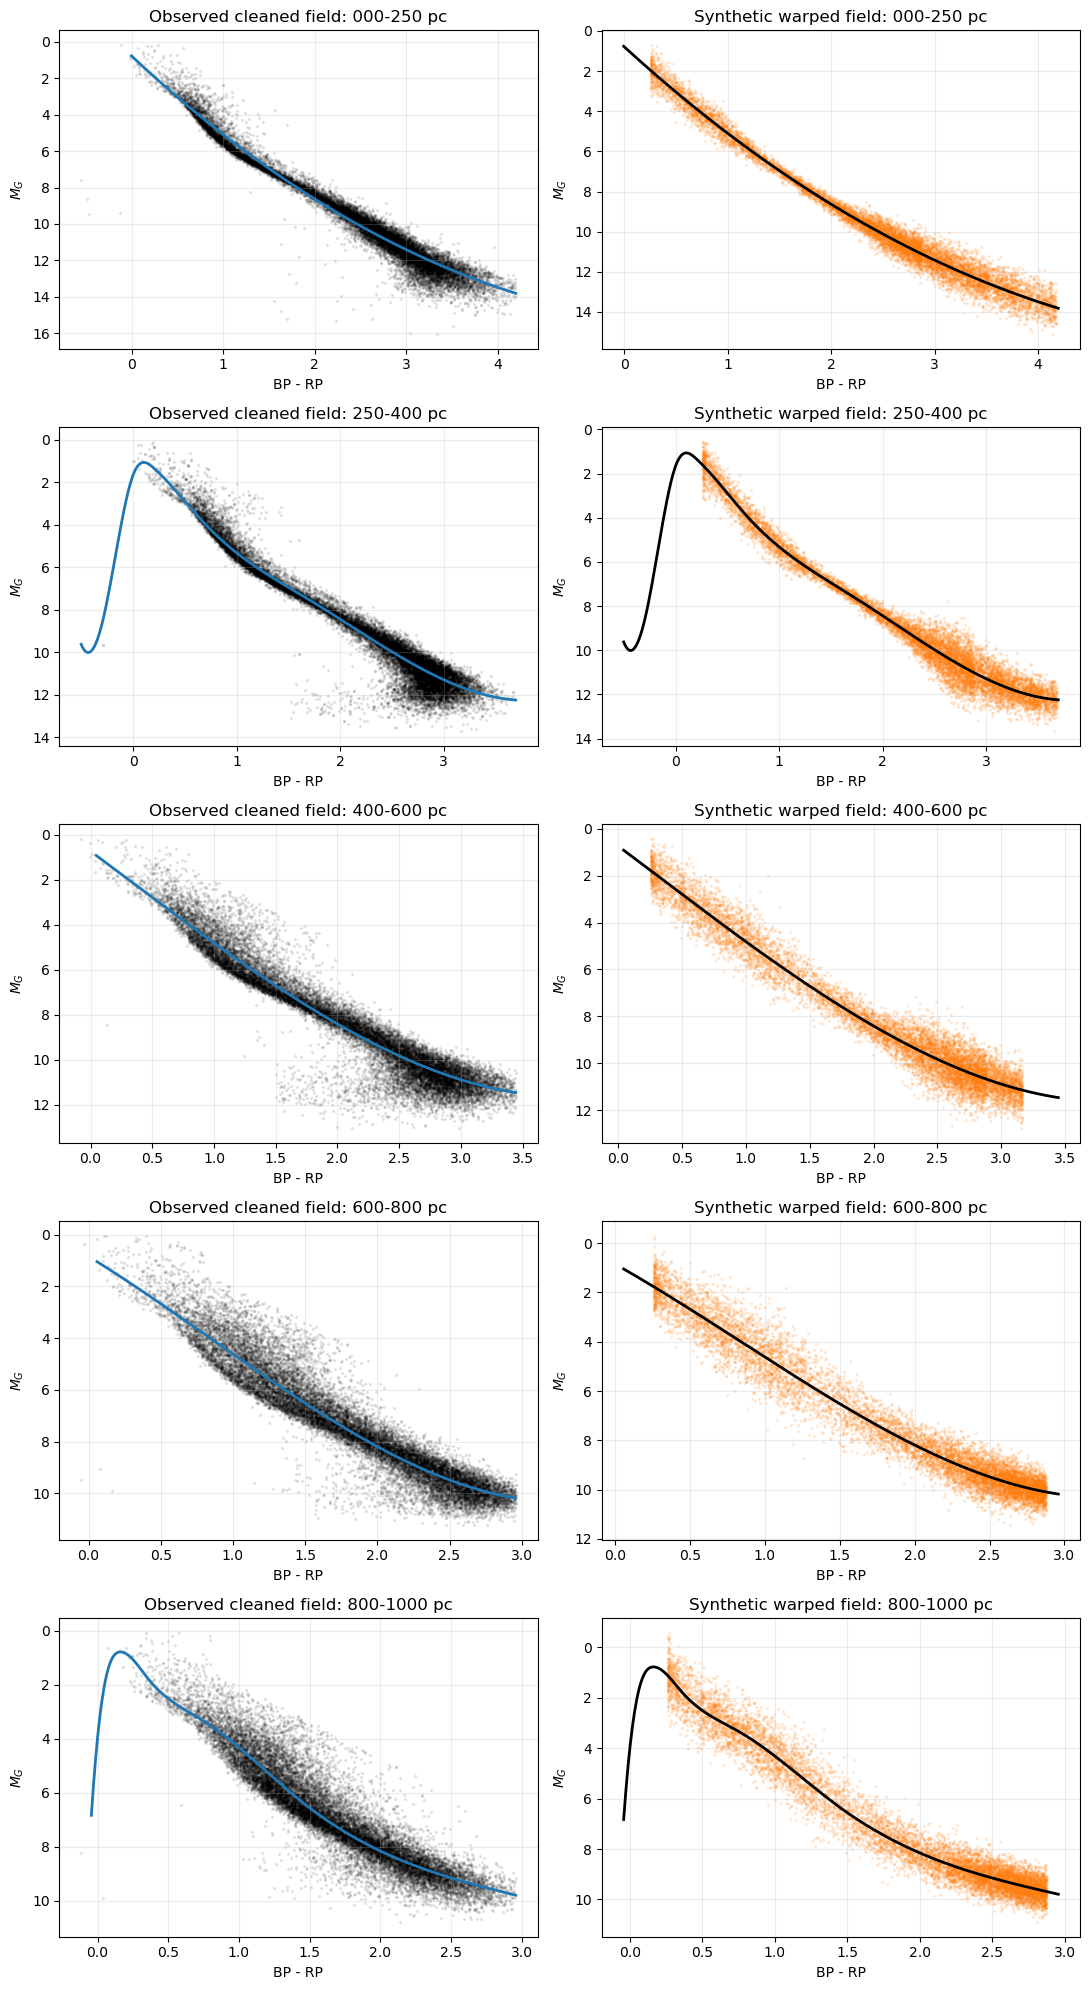

In [35]:
# ============================================================
# Master Field Sequence from all SCYA clusters
# ============================================================

# This cell builds one empirical field sequence per distance bin.
# The idea is:
# 1. Load every SCYA package.
# 2. Estimate the cluster distance from the highest-strength members.
# 3. Put each cluster into a distance bin.
# 4. Stack all stars from clusters in the same bin.
# 5. Apply the same field-quality cuts.
# 6. Fit an empirical spline and sigma_field table for that distance bin.
# 7. Sample the 1 Gyr isochrone and warp it onto that bin's empirical spline.
#
# Main outputs created at the end:
# - cluster_distance_table: one row per SCYA cluster, with its estimated distance.
# - master_field_sequences: dictionary holding all products for each distance bin.
# - master_field_summary: short table summarizing each distance-bin field model.

from pathlib import Path
from scipy.interpolate import UnivariateSpline


# -----------------------------
# Settings
# -----------------------------

SCYA_PKG_DIR = Path("../SCYA_all/SCYA_Pkg")

# These bins are in pc. They cover the SCYA package distances inspected from
# the highest-strength cluster members, which run from about 130 to 990 pc.
DISTANCE_BINS = [0, 250, 400, 600, 800, 1000]
DISTANCE_BIN_LABELS = [
    "000-250 pc",
    "250-400 pc",
    "400-600 pc",
    "600-800 pc",
    "800-1000 pc",
]

# For each cluster, use the top 10 percent highest-strength stars to estimate
# the cluster distance. These are treated as the most central/representative
# members of that SCYA population.
TOP_STRENGTH_FRACTION = 0.10

# Keep stars with low spatially corrected youth probability as field stars.
# Psp is computed below using the same Psp() function defined earlier.
FIELD_PSP_CUT = 0.5

# Settings for the empirical ridge spline in each distance bin.

# MASTER_SMOOTHING_WINDOW smooths sigma_field after measuring the residual width.
# MASTER_CUTOFF_N_FROM_END removes the noisiest red/faint ridge points before fitting.
MASTER_BIN_WIDTH = 0.10 #controls the BP-RP color-bin width used to find median ridge points.
MASTER_MIN_STARS_PER_BIN = 5 #avoids fitting ridge points from tiny noisy bins.
MASTER_SPLINE_SMOOTHING_FACTOR = 0.05 #controls how smooth the spline is.
MASTER_SMOOTHING_WINDOW = 5 #smooths sigma_field after measuring the residual width.
MASTER_CUTOFF_N_FROM_END = 4 #removes the noisiest red/faint ridge points before fitting.

# Use the same synthetic population size as the earlier single-cluster field model.

MASTER_N_SYNTH_PER_BIN = N_SYNTH

# Slanted upper-branch cut. This removes evolved/subgiant-like contamination
# above the main field sequence without chopping the CMD with a horizontal box.

UPPER_BRANCH_COLOR_MIN = 0.8
UPPER_BRANCH_SLOPE = 2.7
UPPER_BRANCH_INTERCEPT = -0.7

# White dwarf box cut. White dwarfs are blue and faint in this CMD region,
# so remove stars with BP-RP < 1.5 and M_G > 10 before fitting the field ridge.

WHITE_DWARF_COLOR_MAX = 1.5
WHITE_DWARF_M_G_MIN = 10.0


# -----------------------------
# Load every SCYA package and estimate cluster distances
# -----------------------------

scya_frames = []
cluster_distance_rows = []

# Loop through every real SCYA cluster CSV, ignoring the macOS metadata files
# because the glob pattern only matches CLUSTER_ALLDATA_SCYA*.csv.
for scya_file in sorted(SCYA_PKG_DIR.glob("CLUSTER_ALLDATA_SCYA*.csv")):
    # Pull the cluster name from the filename, like SCYA6 or SCYA72.
    cluster_name = scya_file.stem.replace("CLUSTER_ALLDATA_", "")
    cluster_data = pd.read_csv(scya_file, encoding="utf-8")

    # Estimate the cluster distance using the highest-strength members.
    # These should sit closest to the population center, so their average d is used as the representative distance for the entire cluster region.
    top_n = max(5, int(len(cluster_data) * TOP_STRENGTH_FRACTION))
    top_strength_members = cluster_data.sort_values("strength", ascending=False).head(top_n)
    cluster_distance = top_strength_members["d"].mean()

    # Add metadata columns that we need after all clusters are stacked together.
    # Psp is recalculated for every cluster so the same field cut can be applied consistently across the whole SCYA package.
    cluster_data["cluster"] = cluster_name
    cluster_data["cluster_distance"] = cluster_distance
    cluster_data["Psp"] = Psp(cluster_data)

    scya_frames.append(cluster_data)

    # Save one summary row per cluster so we can inspect the distance estimate
    # and later assign the whole cluster to a distance bin.
    cluster_distance_rows.append(
        {
            "cluster": cluster_name,
            "N_stars": len(cluster_data),
            "N_top_strength": len(top_strength_members),
            "cluster_distance": cluster_distance,
            "top_strength_min": top_strength_members["strength"].min(),
            "top_strength_max": top_strength_members["strength"].max(),
        }
    )

scya_all = pd.concat(scya_frames, ignore_index=True)
cluster_distance_table = pd.DataFrame(cluster_distance_rows)

# Assign one distance bin to each cluster summary row.
cluster_distance_table["distance_bin"] = pd.cut(
    cluster_distance_table["cluster_distance"],
    bins=DISTANCE_BINS,
    labels=DISTANCE_BIN_LABELS,
    include_lowest=True,
    right=False,
)

# Give every star the distance bin of its parent cluster.
# This is what lets us stack all stars from clusters at similar distances.
scya_all["distance_bin"] = pd.cut(
    scya_all["cluster_distance"],
    bins=DISTANCE_BINS,
    labels=DISTANCE_BIN_LABELS,
    include_lowest=True,
    right=False,
)

print("SCYA clusters loaded:", len(cluster_distance_table))
print("SCYA stars loaded:", len(scya_all))

# Show the nearest clusters as a quick check that the distance estimates look sane.
display(
    cluster_distance_table
    .sort_values("cluster_distance")
    .head(15)
)

print("Clusters per distance bin:")
# This table tells us how many clusters and raw stars contribute to each bin.
display(
    cluster_distance_table
    .groupby("distance_bin", observed=True)
    .agg(
        N_clusters=("cluster", "count"),
        distance_min=("cluster_distance", "min"),
        distance_max=("cluster_distance", "max"),
        N_stars=("N_stars", "sum"),
    )
    .reset_index()
)


# -----------------------------
# Build one master field sequence per distance bin
# -----------------------------

master_field_sequences = {}
master_summary_rows = []

# Run the full field-modeling workflow independently for each distance bin.
# Each bin gets its own observed field sample, spline, sigma_field table,
# and synthetic warped field population.
for distance_bin in DISTANCE_BIN_LABELS:
    print("\n" + "=" * 70) 
    print(f"Building master field sequence for {distance_bin}")
    print("=" * 70)

    # Pull all stars whose parent cluster belongs to this distance bin.
    # Then add BP-RP and absolute G magnitude columns for CMD work.
    bin_raw = scya_all[scya_all["distance_bin"] == distance_bin].copy()
    bin_raw = add_cmd_columns(bin_raw)

    # Start the clean-field mask by keeping stars that are unlikely to be
    # young cluster members, have finite Pyoung, and have valid CMD coordinates.
    field_mask = bin_raw["Psp"] < FIELD_PSP_CUT
    field_mask &= np.isfinite(bin_raw["Pyoung"])
    field_mask &= np.isfinite(bin_raw["bp_rp"])
    field_mask &= np.isfinite(bin_raw["M_G"])

    # Remove very bright OB/massive stars. They are not part of the older
    # background field sequence we want to fit.
    field_mask &= bin_raw["M_G"] > 0.0

    # Remove the blue/faint white dwarf box before fitting the main field ridge.
    # This catches BP-RP < 1.5, including negative BP-RP white dwarfs.
    white_dwarf_cut = (
        (bin_raw["bp_rp"] < WHITE_DWARF_COLOR_MAX)
        & (bin_raw["M_G"] > WHITE_DWARF_M_G_MIN)
    )

    # Build the slanted upper-branch boundary in CMD space.
    # Stars brighter than this boundary at red colors are removed.
    upper_branch_boundary = (
        UPPER_BRANCH_SLOPE * bin_raw["bp_rp"]
        + UPPER_BRANCH_INTERCEPT
    )

    upper_branch_cut = (
        (bin_raw["bp_rp"] > UPPER_BRANCH_COLOR_MIN)
        & (bin_raw["M_G"] < upper_branch_boundary)
    )

    # Apply the white dwarf cut first and count how many stars it removes.
    removed_white_dwarfs = field_mask & white_dwarf_cut
    field_mask &= ~white_dwarf_cut

    # Then apply the upper-branch cut to the stars still surviving the field mask.
    removed_upper_branch = field_mask & upper_branch_cut
    field_mask &= ~upper_branch_cut

    # This is the observed cleaned field sample used to fit the empirical ridge
    # for this distance bin.
    bin_field_clean = bin_raw[field_mask].copy()

    print(f"Raw stars in bin:      {len(bin_raw):,}")
    print(f"Clean field stars:     {len(bin_field_clean):,}")
    print(f"Removed white dwarfs:  {removed_white_dwarfs.sum():,}")
    print(f"Removed upper branch:  {removed_upper_branch.sum():,}")


    # -----------------------------
    # Fit empirical ridge spline
    # -----------------------------

    field_with_ridge = bin_field_clean.copy()

    # Build BP-RP bins across the cleaned field sample.
    # Each bin will contribute one median CMD ridge point.
    color_min = field_with_ridge["bp_rp"].min()
    color_max = field_with_ridge["bp_rp"].max()

    bin_edges = np.arange(color_min, color_max + MASTER_BIN_WIDTH, MASTER_BIN_WIDTH)

    field_with_ridge["color_bin"] = np.digitize(
        field_with_ridge["bp_rp"],
        bin_edges,
    ) - 1

    ridge_rows = []

    # For each color bin, find the median M_G value.
    # These medians are the raw empirical ridge points before smoothing.
    for bin_number in range(len(bin_edges) - 1):
        in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

        if len(in_bin) < MASTER_MIN_STARS_PER_BIN:
            continue

        color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1])
        median_M_G = np.median(in_bin["M_G"])

        ridge_rows.append(
            {
                "bp_rp_center": color_center,
                "M_G_ridge_raw": median_M_G,
                "N_stars": len(in_bin),
            }
        )

    ridge_points = pd.DataFrame(ridge_rows)
    ridge_points = ridge_points.sort_values("bp_rp_center").reset_index(drop=True)

    # Drop the last few red/faint ridge points because the edge often bends
    # upward from noise or contamination rather than tracing the real sequence.
    ridge_points_fit = ridge_points.iloc[:-MASTER_CUTOFF_N_FROM_END].copy()
    bp_rp_cutoff = ridge_points_fit["bp_rp_center"].max()

    x_ridge = ridge_points_fit["bp_rp_center"].values
    y_ridge = ridge_points_fit["M_G_ridge_raw"].values

    spline_smoothing = len(ridge_points_fit) * MASTER_SPLINE_SMOOTHING_FACTOR

    # Fit a smooth curve through the median ridge points.
    # This spline is the empirical field ridge for this distance bin.
    bin_ridge_spline = UnivariateSpline(
        x_ridge,
        y_ridge,
        s=spline_smoothing,
    )

    ridge_points_fit["M_G_ridge_spline"] = bin_ridge_spline(x_ridge)

    # Keep only stars inside the fitted spline color range so we do not use
    # the spline in the noisy red-end region that was cut away.
    field_with_ridge = field_with_ridge[
        field_with_ridge["bp_rp"] <= bp_rp_cutoff
    ].copy()

    # For every observed field star, evaluate the spline at that star's BP-RP.
    # This gives the expected ridge M_G at the same color.
    field_with_ridge["M_G_ridge"] = bin_ridge_spline(
        field_with_ridge["bp_rp"].values
    )

    # The residual measures how far above/below the ridge each real field star is.
    # These residuals are used to measure the field sequence width.
    field_with_ridge["M_G_residual"] = (
        field_with_ridge["M_G"] - field_with_ridge["M_G_ridge"]
    )


    # -----------------------------
    # Measure sigma_field around the spline
    # -----------------------------

    sigma_rows = []

    # Go back through the same color bins and measure the spread of residuals
    # around the spline. This gives sigma_field(BP-RP) for this distance bin.
    for bin_number in range(len(bin_edges) - 1):
        in_bin = field_with_ridge[field_with_ridge["color_bin"] == bin_number]

        if len(in_bin) < MASTER_MIN_STARS_PER_BIN:
            continue

        color_center = 0.5 * (bin_edges[bin_number] + bin_edges[bin_number + 1])

        # q16 and q84 enclose the central 68 percent of the residuals.
        # Half of that width is used as a robust sigma estimate.
        q16 = np.percentile(in_bin["M_G_residual"], 16)
        q50 = np.percentile(in_bin["M_G_residual"], 50)
        q84 = np.percentile(in_bin["M_G_residual"], 84)

        sigma_rows.append(
            {
                "bp_rp_center": color_center,
                "residual_median": q50,
                "sigma_field": 0.5 * (q84 - q16),
                "N_stars": len(in_bin),
            }
        )

    bin_sigma_table = pd.DataFrame(sigma_rows)

    # Smooth the sigma values so one weird color bin does not create an
    # artificial spike in the synthetic field scatter.
    bin_sigma_table["sigma_field_smooth"] = bin_sigma_table["sigma_field"].rolling(
        window=MASTER_SMOOTHING_WINDOW,
        center=True,
        min_periods=1,
    ).median()


    # -----------------------------
    # Prepare the 1 Gyr isochrone over this bin's color range
    # -----------------------------

    empirical_color_min = max(
        ridge_points_fit["bp_rp_center"].min(),
        bin_sigma_table["bp_rp_center"].min(),
    )

    empirical_color_max = min(
        ridge_points_fit["bp_rp_center"].max(),
        bin_sigma_table["bp_rp_center"].max(),
    )

    # Start again from the 1 Gyr PARSEC isochrone and keep only labels 0/1,
    # which are the main-sequence part of the isochrone backbone.
    bin_iso_backbone = iso_1gyr[iso_1gyr["label"].isin([0, 1])].copy()

    # Create the mass coordinate and CMD columns needed for interpolation.
    bin_iso_backbone["mass_sample"] = bin_iso_backbone["Mini"]
    bin_iso_backbone["bp_rp"] = bin_iso_backbone["G_BPmag"] - bin_iso_backbone["G_RPmag"]
    bin_iso_backbone["M_G"] = bin_iso_backbone["Gmag"]

    # Restrict the theoretical backbone to the same color interval where the
    # empirical spline and sigma table are defined for this distance bin.
    bin_iso_backbone = bin_iso_backbone[
        bin_iso_backbone["bp_rp"].between(empirical_color_min, empirical_color_max)
    ].copy()

    # Keep only the columns needed to map sampled masses to Gaia CMD values.
    bin_iso_interp = bin_iso_backbone[
        [
            "mass_sample",
            "Mass",
            "Gmag",
            "G_BPmag",
            "G_RPmag",
            "bp_rp",
            "M_G",
            "label",
        ]
    ].copy()

    # Clean the interpolation table and sort it by mass because np.interp
    # expects the x-axis values to increase monotonically.
    bin_iso_interp = (
        bin_iso_interp
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("mass_sample")
        .drop_duplicates(subset="mass_sample", keep="first")
        .reset_index(drop=True)
    )


    # -----------------------------
    # Sample the 1 Gyr backbone and warp it to this distance-bin spline
    # -----------------------------

    m_min = bin_iso_interp["mass_sample"].min()
    m_max = bin_iso_interp["mass_sample"].max()

    # Draw synthetic stellar masses from the Chabrier IMF, limited to the mass
    # range covered by this distance bin's usable 1 Gyr isochrone backbone.
    synth_mass = sample_chabrier_2005_imf(
        size=MASTER_N_SYNTH_PER_BIN,
        m_min=m_min,
        m_max=m_max,
        rng=rng,
    )

    bin_synth = pd.DataFrame({"mass_sample": synth_mass})

    # Convert every sampled mass into theoretical Gaia magnitudes/color by
    # interpolating along the 1 Gyr isochrone table.
    for col in ["Gmag", "G_BPmag", "G_RPmag", "bp_rp", "M_G"]:
        bin_synth[col] = np.interp(
            bin_synth["mass_sample"],
            bin_iso_interp["mass_sample"],
            bin_iso_interp[col],
        )

    # Warp the theoretical backbone vertically onto the empirical field ridge.
    # The BP-RP color stays fixed; M_G_ridge comes from the observed spline.
    bin_synth["M_G_ridge"] = bin_ridge_spline(bin_synth["bp_rp"])

    # Give each synthetic star the observed field width at its BP-RP color.
    bin_synth["sigma_field"] = np.interp(
        bin_synth["bp_rp"],
        bin_sigma_table["bp_rp_center"],
        bin_sigma_table["sigma_field_smooth"],
    )

    # Add vertical scatter around the empirical ridge using the measured
    # sigma_field for this distance bin.
    bin_synth["M_G_synth"] = bin_synth["M_G_ridge"] + rng.normal(
        loc=0.0,
        scale=bin_synth["sigma_field"],
        size=len(bin_synth),
    )

    # Tag the synthetic stars with the distance bin that created them.
    bin_synth["distance_bin"] = distance_bin

    # Save the list of real SCYA clusters that contributed to this bin.
    clusters_in_bin = (
        cluster_distance_table[cluster_distance_table["distance_bin"] == distance_bin]
        .sort_values("cluster_distance")
        .copy()
    )

    # Store all useful products for this distance bin in one dictionary entry.
    # This makes it easy to inspect a bin later, e.g.
    # master_field_sequences["400-600 pc"]["synthetic_field"].
    master_field_sequences[distance_bin] = {
        "clusters": clusters_in_bin,
        "field_raw": bin_raw,
        "field_clean": bin_field_clean,
        "field_with_ridge": field_with_ridge,
        "ridge_points": ridge_points,
        "ridge_points_fit": ridge_points_fit,
        "ridge_spline": bin_ridge_spline,
        "sigma_table": bin_sigma_table,
        "iso_interp": bin_iso_interp,
        "synthetic_field": bin_synth,
    }

    # Add one compact summary row for quick comparison across distance bins.
    master_summary_rows.append(
        {
            "distance_bin": distance_bin,
            "N_clusters": len(clusters_in_bin),
            "N_raw_stars": len(bin_raw),
            "N_clean_field": len(bin_field_clean),
            "N_ridge_points": len(ridge_points_fit),
            "BP_RP_min": empirical_color_min,
            "BP_RP_max": empirical_color_max,
            "median_sigma_field": bin_sigma_table["sigma_field_smooth"].median(),
            "N_synthetic": len(bin_synth),
        }
    )

    print(f"Spline color range:  {empirical_color_min:.3f} to {empirical_color_max:.3f}")
    print(f"Synthetic stars:     {len(bin_synth):,}")
    print(f"Median sigma_field:  {bin_sigma_table['sigma_field_smooth'].median():.3f}")

master_field_summary = pd.DataFrame(master_summary_rows)

# This summary table is the quick overview of the final master field models.
print("\nMaster field sequence summary:")
display(master_field_summary)


# -----------------------------
# Quick diagnostic plot
# -----------------------------

fig, axes = plt.subplots(
    len(DISTANCE_BIN_LABELS),
    2,
    figsize=(11, 4 * len(DISTANCE_BIN_LABELS)),
    sharex=False,
    sharey=False,
)

# Make one row per distance bin.
# Left panel: observed cleaned field plus the fitted empirical spline.
# Right panel: synthetic field after the 1 Gyr backbone has been warped to that spline.
for row_number, distance_bin in enumerate(DISTANCE_BIN_LABELS):
    result = master_field_sequences[distance_bin]

    field_plot = result["field_with_ridge"]
    synth_plot = result["synthetic_field"]
    ridge_plot = result["ridge_points_fit"]
    spline = result["ridge_spline"]

    # Downsample large bins for plotting only, so the figure stays responsive.
    # The stored dataframes above still contain the full samples.
    field_plot_sample = field_plot.sample(
        n=min(len(field_plot), 20000),
        random_state=RNG_SEED,
    )

    synth_plot_sample = synth_plot.sample(
        n=min(len(synth_plot), 10000),
        random_state=RNG_SEED,
    )

    # Color grid used to draw the fitted spline curve smoothly.
    color_grid = np.linspace(
        ridge_plot["bp_rp_center"].min(),
        ridge_plot["bp_rp_center"].max(),
        400,
    )

    axes[row_number, 0].scatter(
        field_plot_sample["bp_rp"],
        field_plot_sample["M_G"],
        s=2,
        alpha=0.08,
        color="black",
        rasterized=True,
    )

    axes[row_number, 0].plot(
        color_grid,
        spline(color_grid),
        color="tab:blue",
        lw=2,
    )

    axes[row_number, 0].invert_yaxis()
    axes[row_number, 0].set_title(f"Observed cleaned field: {distance_bin}")
    axes[row_number, 0].set_xlabel("BP - RP")
    axes[row_number, 0].set_ylabel(r"$M_G$")
    axes[row_number, 0].grid(alpha=0.25)

    axes[row_number, 1].scatter(
        synth_plot_sample["bp_rp"],
        synth_plot_sample["M_G_synth"],
        s=2,
        alpha=0.12,
        color="tab:orange",
        rasterized=True,
    )

    axes[row_number, 1].plot(
        color_grid,
        spline(color_grid),
        color="black",
        lw=2,
    )

    axes[row_number, 1].invert_yaxis()
    axes[row_number, 1].set_title(f"Synthetic warped field: {distance_bin}")
    axes[row_number, 1].set_xlabel("BP - RP")
    axes[row_number, 1].set_ylabel(r"$M_G$")
    axes[row_number, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Pre-Main Sequence

#### Stage 2: Creating a Synthetic Pre-Main Sequence Population Model:

Now we want to model the young/pre-main sequence population rather than the older field sequence.

The main difference from the field model is that the PMS population should probably be handled cluster-by-cluster. The field sequence is essentially able to be modeled as a single age because it is well mixed. More specifically, the milky way is relatively well mixed where there is no specific ages depending on where you are within the milky way, so we were able to plot one empirical model with a backbone of a 1Gyr isochrone. However, the young sequence depends strongly on cluster age, distance, extinction, and possible age spread.

##### 2a) Select the Young PMS Sample

For each cluster separately, start from the stars that are likely to belong to the young population:

- Require Pyoung to be defined
- Require Psp > 0.5
- Convert to CMD space using BP-RP and absolute G magnitude

This should remove most giant branch stars, white dwarfs, and field contaminants because those objects should not survive the Psp > 0.5 cut.

##### 2b) Fit an Empirical PMS Ridge for Each Cluster

In each cluster CMD, fit a smooth spline through the young PMS sequence.

- Bin in BP-RP color
- Estimate the typical PMS magnitude in each bin, probably with a median or robust percentile
- Fit/smooth a spline through those ridge points
- Restrict the fit to the color range where the PMS is actually well populated

This spline is the empirical PMS ridge for that cluster.

##### 2c) Measure the PMS Width Around the Ridge

For each color bin, measure the scatter of young stars around the PMS ridge.

- Compute vertical residuals: M_G star - M_G PMS ridge
- Estimate sigma_PMS(BP-RP) from the central 68 percent width or another robust scatter metric
- Smooth sigma_PMS as a function of color

This width includes real effects like unresolved binaries, age spread, photometric noise, and remaining contamination.

##### 2d) Choose the Best-Matching Isochrone Age per Cluster

This is the big difference from the field sequence. Instead of assuming we have a 1Gyr isochrone as the backbone of the distirbution, fit the isochrone age separately for each one.

- Load a grid of young isochrones
- Put each isochrone into the same CMD space as the data
- Compare each isochrone to the empirical PMS spline over the valid PMS color range
- Use a least-squares or chi-square score between the isochrone and the spline
- Pick the age with the minimum score for that cluster

The isochrone is used as the physical sampling backbone, while the empirical spline tells us how the observed cluster sequence actually sits in the CMD.
- For now the plan is not to warp the best-fitting isocohrone to the spline, because the isochrone age has physical meaning in the pre-main sequence and we don't want to get rid of that meaning by warping it
- Perhaps we will allow more global changes if needed including magnitude shift or colour shift, redenning correction or something but for now we will leave it

##### 2e) Generate the Synthetic PMS Population

For each cluster, generate synthetic stars from the best-fitting young isochrone.

- Sample masses from an IMF or from the observed luminosity/color distribution

**For now, we will leave out:**
- unresolved binaries
- redenning
- Optionally warp/shift the synthetic stars so their ridge follows the empirical PMS spline

This creates a cluster-specific synthetic PMS population instead of forcing every cluster to share one young sequence.

##### 2f) Validate Against the Observed Young Population

Compare the synthetic PMS CMD to the observed Psp-selected young sample for each cluster.

- Check the ridge location
- Check the sequence width
- Check the luminosity/color distribution
- Check whether the model overproduces or underproduces stars in specific CMD regions

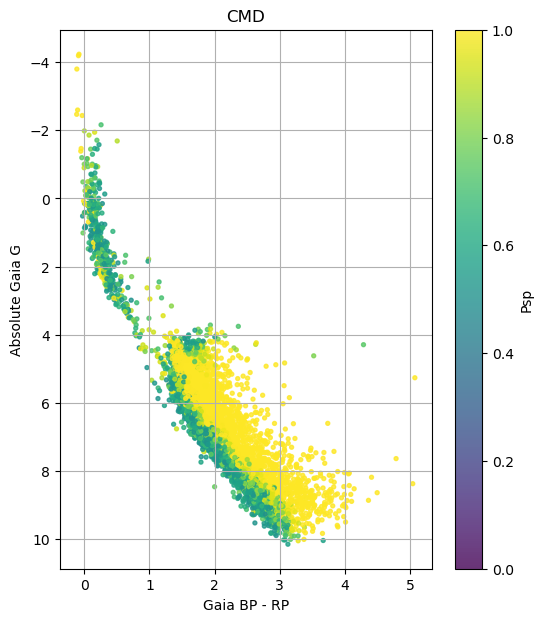

In [36]:
plot_cmd_highlight(df_6, psp_cut=0.5)